# Joint Fermi-LAT + CTA + SWGO detectability forecast: HESS J1837-069 / PSR J1838-0655



## Imports

In [1]:
from __future__ import annotations
import warnings, logging, pathlib, copy, os
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
import matplotlib.pyplot as plt
from pathlib import Path

import gammapy
from gammapy.maps import WcsGeom, Map, MapAxis
from gammapy.irf import load_irf_dict_from_file, EDispKernelMap
from gammapy.data import Observation
from gammapy.datasets import MapDataset, Datasets
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.modeling.models import (
    SkyModel, Models, FoVBackgroundModel,
    PointSpatialModel, GaussianSpatialModel, TemplateSpatialModel,
    ExpCutoffPowerLawSpectralModel, PowerLawSpectralModel, PowerLawNormSpectralModel,
)
from gammapy.modeling import Fit
from gammapy.estimators import TSMapEstimator, FluxPointsEstimator

logging.basicConfig(level=logging.WARNING)
log = logging.getLogger(__name__)
print(f"Gammapy version: {gammapy.__version__}")
print("✓ Imports complete")


Gammapy version: 2.0.1
✓ Imports complete


## Shared thesis plot style

In [2]:
import matplotlib as mpl

THESIS_FONT_SIZE_PT = 11  # matches \documentclass[11pt,...]{report}

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Latin Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,

    "font.size": THESIS_FONT_SIZE_PT,
    "axes.labelsize": THESIS_FONT_SIZE_PT,
    "xtick.labelsize": THESIS_FONT_SIZE_PT,
    "ytick.labelsize": THESIS_FONT_SIZE_PT,
    "axes.titlesize": THESIS_FONT_SIZE_PT,
    "legend.fontsize": THESIS_FONT_SIZE_PT - 1,
    "figure.titlesize": THESIS_FONT_SIZE_PT + 1,

    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.frameon": False,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## Shared target configuration

Same PWN + TeV-halo parameters used in `CT2hess10physicalmodelfixed.py` and
`PeVhess10physicalmodelfixed.py`, kept as a single source of truth here since all three
instruments must share the exact same injected/fitted target. The only change from those two
scripts: the PWN's spectral model is `ExpCutoffPowerLawSpectralModel` instead of `PowerLaw`
(the halo keeps its own `PowerLaw` spectrum, unchanged).

In [3]:
# ── Target position (common reference-grid centre too, see below) ────────────────────────────────
# Chandra ACIS-I / RXTE timing position of PSR J1838-0655 (Gotthelf & Halpern 2008,
# ApJ 681, L1, Table 3) -- same anchor used in both per-instrument scripts. Using it
# directly as the common grid's centre below means no per-instrument RA/Dec offset
# workaround is needed (unlike the SWGO-only script's SOURCE_OFFSET_RA/DEC_DEG, which
# only existed because that pre-baked benchmark dataset's own FoV centre wasn't exactly
# on the pulsar).
SOURCE_CENTER = SkyCoord(ra=279.5130417 * u.deg, dec=-6.9259444 * u.deg, frame="icrs")

SEED = 42

# ── PWN (point source) spectral TRUTH, ECPL ───────────────────────────────────────
# HESS 2018 (HGPS) power-law normalization/index -- the same numbers used as the PL
# truth in both per-instrument scripts, reused here as the ECPL amplitude/index (ECPL
# reduces to a plain power law as lambda_ -> 0). No cutoff has actually been measured
# for HESS J1837-069, so PWN_LAMBDA_ is set to the same lambda_="0.1 TeV-1" (E_cutoff=10
# TeV) starting value already used for the joint HAWC+Fermi-LAT ECPL fit earlier in this
# project -- a documented placeholder, not a literature value, free to move in the fit.
PWN_AMPLITUDE = 1.779e-11 * u.Unit("cm-2 s-1 TeV-1")   # HESS 2018 (HGPS)
PWN_INDEX     = 2.54                                    # HESS 2018 (HGPS)
PWN_E_REF     = 1.0 * u.TeV
PWN_LAMBDA_   = 1 / (10.0 * u.TeV)                      # E_cutoff = 10 TeV, PLACEHOLDER

# ── TeV halo spectral + shape TRUTH (unchanged from both per-instrument scripts) ─────
HALO_ALPHA     = 2.54                                   # HESS 2018 mean spectral index
HALO_E0        = 0.95 * u.TeV                           # HGPS spectral pivot
HALO_AMPLITUDE = 2.00e-11 * u.Unit("cm-2 s-1 TeV-1")     # HGPS diff. flux at HALO_E0
HESS2006_SIGMA_MAJOR_DEG = 0.12                          # Aharonian+2006 measured size
HALO_THETA_D0  = HESS2006_SIGMA_MAJOR_DEG * u.deg
HALO_THETA_E0  = HALO_E0
HALO_AXIS_RATIO     = 0.05 / 0.12                        # HESS 2006 minor/major axis
HALO_POSITION_ANGLE = 86.3                               # deg, East of North (ICRS)
HALO_OFFSET_DEG     = 0.5 * HALO_THETA_D0.to_value(u.deg)
HALO_OFFSET_PA_DEG  = 270.0

# Physical (cooling + proper-motion) template inputs -- generic middle-aged-pulsar
# values, same as both per-instrument scripts (none separately measured for this source).
DELTA_DIFF            = 0.33
T_AGE_YR              = 23e3    # PSR J1838-0655 characteristic age
DIST_KPC              = 6.6     # assumed, via star-cluster association (HESS 2018)
HALO_TAU0_KYR         = 5.0
HALO_U_TOTAL_EV_CM3   = 1.0
HALO_CUTOFF_TEV       = 100.0
HALO_INJECTION_INDEX  = HALO_ALPHA
HALO_V_TRANSVERSE_KMS = 0.0
HALO_MOTION_PA_DEG    = 0.0
HALO_N_TIME_SLICES    = 48

print("✓ Shared target configuration set (PWN: ECPL, halo: PowerLaw + physical template)")


✓ Shared target configuration set (PWN: ECPL, halo: PowerLaw + physical template)


## Physical (cooling + proper-motion) halo-template functions

Verbatim from `CT2hess10physicalmodelfixed.py` / `PeVhess10physicalmodelfixed.py` (identical in both).

In [4]:
KYR_TO_S_PHYS       = 1.0e3 * 365.25 * 24.0 * 3600.0
PC_TO_CM_PHYS       = 3.085677581e18
RAD_TO_DEG_PHYS     = 180.0 / np.pi
KM_S_KYR_TO_PC_PHYS = 1.022712e-3


def _electron_energy_from_gamma_tev(Egamma_TeV):
    """IC-on-CMB Thomson-limit electron energy for a given gamma-ray energy."""
    return 17.6 * np.sqrt(np.asarray(Egamma_TeV, dtype=float))


def _cooling_time_kyr(Eelectron_TeV, u_total_eV_cm3):
    return 300.0 / (np.asarray(Eelectron_TeV, dtype=float) * u_total_eV_cm3)


def _diffusion_coefficient_cm2_s(Eelectron_TeV, D100_cm2_s, diffusion_index):
    return D100_cm2_s * (np.asarray(Eelectron_TeV, dtype=float) / 100.0) ** diffusion_index


def halo_spatial_template_physical(
    Egamma_TeV, xx_deg, yy_deg,
    age_kyr, distance_kpc, tau0_kyr,
    injection_index, cutoff_TeV,
    D100_cm2_s, diffusion_index, u_total_eV_cm3,
    v_transverse_kms=0.0, motion_angle_rad=0.0,
    axis_ratio=1.0, position_angle_deg=0.0,
    n_time_slices=48, pixel_size_deg=None,
):
    """Normalised 2D template for one gamma-ray energy bin, from pulsar spin-down +
    electron cooling + proper motion + diffusion."""
    Ee = float(_electron_energy_from_gamma_tev(Egamma_TeV))
    tcool = float(_cooling_time_kyr(Ee, u_total_eV_cm3))

    tmax = min(float(age_kyr), 0.98 * tcool)
    tmax = max(tmax, 1.0e-3)

    u_grid = np.linspace(0.0, 1.0, n_time_slices)
    lookback_kyr = tmax * u_grid**2
    dt = np.gradient(lookback_kyr)

    cooling_fraction = np.clip(1.0 - lookback_kyr / tcool, 0.02, None)
    Einj = Ee / cooling_fraction

    source_age_at_injection = np.maximum(age_kyr - lookback_kyr, 0.0)
    spin_down_ratio = (
        (1.0 + age_kyr / tau0_kyr)
        / (1.0 + source_age_at_injection / tau0_kyr)
    ) ** 2

    injection_weight = (
        spin_down_ratio
        * (Einj / Ee) ** (-injection_index)
        * np.exp(-Einj / cutoff_TeV)
        / cooling_fraction**2
        * dt
    )
    injection_weight = np.nan_to_num(injection_weight, nan=0.0, posinf=0.0, neginf=0.0)
    if injection_weight.sum() <= 0.0:
        injection_weight = np.ones_like(injection_weight)
    injection_weight /= injection_weight.sum()

    D = _diffusion_coefficient_cm2_s(Einj, D100_cm2_s, diffusion_index)
    sigma_diff_pc = np.sqrt(2.0 * D * lookback_kyr * KYR_TO_S_PHYS) / PC_TO_CM_PHYS
    sigma_diff_deg = sigma_diff_pc / (1000.0 * distance_kpc) * RAD_TO_DEG_PHYS

    sigma_total_deg = sigma_diff_deg
    if pixel_size_deg is not None:
        sigma_total_deg = np.maximum(sigma_total_deg, 0.25 * pixel_size_deg)

    displacement_pc = v_transverse_kms * lookback_kyr * KM_S_KYR_TO_PC_PHYS
    center_x_deg = (
        -displacement_pc * np.cos(motion_angle_rad)
        / (1000.0 * distance_kpc) * RAD_TO_DEG_PHYS
    )
    center_y_deg = (
        -displacement_pc * np.sin(motion_angle_rad)
        / (1000.0 * distance_kpc) * RAD_TO_DEG_PHYS
    )

    template = np.zeros_like(xx_deg, dtype=float)
    _pa_rad = np.radians(position_angle_deg)
    for weight, cx, cy, sigma in zip(
        injection_weight, center_x_deg, center_y_deg, sigma_total_deg
    ):
        dx = xx_deg - cx
        dy = yy_deg - cy
        if axis_ratio != 1.0:
            x_rot = dx * np.sin(_pa_rad) + dy * np.cos(_pa_rad)
            y_rot = -dx * np.cos(_pa_rad) + dy * np.sin(_pa_rad)
            r2 = x_rot**2 + (y_rot / axis_ratio) ** 2
        else:
            r2 = dx**2 + dy**2
        template += weight * np.exp(-0.5 * r2 / sigma**2) / (2.0 * np.pi * sigma**2)

    template = np.clip(template, 0.0, None)
    norm = template.sum()
    if not np.isfinite(norm) or norm <= 0.0:
        raise RuntimeError("Physical halo template normalization failed")
    return template / norm


def build_physical_halo_template(
    geom_3d, center,
    age_kyr, distance_kpc, tau0_kyr,
    injection_index, cutoff_TeV,
    D100_cm2_s, diffusion_index, u_total_eV_cm3,
    spectral_index, spectral_e0_TeV,
    v_transverse_kms=0.0, motion_angle_deg=0.0,
    axis_ratio=1.0, position_angle_deg=0.0,
    offset_deg=0.0, offset_pa_deg=None,
    n_time_slices=48,
):
    """Build the energy-dependent physical halo template on geom_3d's grid and
    energy-integrate it into a single normalised 2D Map for TemplateSpatialModel."""
    halo_center = center
    if offset_deg:
        _pa = offset_pa_deg if offset_pa_deg is not None else position_angle_deg
        halo_center = center.directional_offset_by(_pa * u.deg, offset_deg * u.deg)

    geom_img = geom_3d.to_image()
    coords = geom_img.get_coord()
    dlon, dlat = halo_center.spherical_offsets_to(coords.skycoord)
    xx_deg = dlon.to_value(u.deg)
    yy_deg = dlat.to_value(u.deg)
    pixel_size_deg = geom_img.pixel_scales.mean().to_value(u.deg)

    e_centers = geom_3d.axes["energy"].center.to_value(u.TeV)
    motion_angle_rad = np.radians(motion_angle_deg)

    ny, nx = xx_deg.shape
    cube = np.zeros((len(e_centers), ny, nx))
    for ie, Egamma_TeV in enumerate(e_centers):
        cube[ie] = halo_spatial_template_physical(
            Egamma_TeV, xx_deg, yy_deg,
            age_kyr=age_kyr, distance_kpc=distance_kpc, tau0_kyr=tau0_kyr,
            injection_index=injection_index, cutoff_TeV=cutoff_TeV,
            D100_cm2_s=D100_cm2_s, diffusion_index=diffusion_index,
            u_total_eV_cm3=u_total_eV_cm3,
            v_transverse_kms=v_transverse_kms, motion_angle_rad=motion_angle_rad,
            axis_ratio=axis_ratio, position_angle_deg=position_angle_deg,
            n_time_slices=n_time_slices, pixel_size_deg=pixel_size_deg,
        )

    spectral_weight = (e_centers / spectral_e0_TeV) ** (-spectral_index)
    phi_2d = np.trapezoid(cube * spectral_weight[:, None, None], x=e_centers, axis=0)
    phi_2d = phi_2d / np.nanmax(phi_2d)
    phi_map = Map.from_geom(geom_img)
    phi_map.quantity = phi_2d * u.Unit("")
    return phi_map, cube


def _physical_template_effective_sigma_deg(
    Egamma_TeV, D100_cm2_s,
    age_kyr, distance_kpc, tau0_kyr,
    injection_index, cutoff_TeV, diffusion_index, u_total_eV_cm3,
    n_time_slices=48, half_width_deg=3.0, n_grid=241,
):
    """RMS radius (deg) of the circular, un-offset physical template at one gamma-ray
    energy, for a trial diffusion coefficient -- used only to calibrate D100 against a
    measured size."""
    axis = np.linspace(-half_width_deg, half_width_deg, n_grid)
    xx, yy = np.meshgrid(axis, axis, indexing="xy")
    _calib_pixel_deg = 2.0 * half_width_deg / (n_grid - 1)
    template = halo_spatial_template_physical(
        Egamma_TeV, xx, yy,
        age_kyr=age_kyr, distance_kpc=distance_kpc, tau0_kyr=tau0_kyr,
        injection_index=injection_index, cutoff_TeV=cutoff_TeV,
        D100_cm2_s=D100_cm2_s, diffusion_index=diffusion_index,
        u_total_eV_cm3=u_total_eV_cm3, n_time_slices=n_time_slices,
        pixel_size_deg=_calib_pixel_deg,
    )
    r2 = xx**2 + yy**2
    return float(np.sqrt(np.sum(template * r2)))


def calibrate_physical_D100_cm2_s(
    target_sigma_deg, target_energy_TeV,
    age_kyr, distance_kpc, tau0_kyr,
    injection_index, cutoff_TeV, diffusion_index, u_total_eV_cm3,
    n_time_slices=48, log10_D100_bounds=(22.0, 30.0),
):
    """Solve for the D100 (diffusion coefficient at 100 TeV) that makes the physical
    halo template's RMS radius at target_energy_TeV equal target_sigma_deg."""
    from scipy.optimize import brentq

    def resid(log10_D100):
        D100 = 10.0 ** log10_D100
        sigma = _physical_template_effective_sigma_deg(
            target_energy_TeV, D100,
            age_kyr=age_kyr, distance_kpc=distance_kpc, tau0_kyr=tau0_kyr,
            injection_index=injection_index, cutoff_TeV=cutoff_TeV,
            diffusion_index=diffusion_index, u_total_eV_cm3=u_total_eV_cm3,
            n_time_slices=n_time_slices,
        )
        return sigma - target_sigma_deg

    lo, hi = log10_D100_bounds
    if resid(lo) > 0 or resid(hi) < 0:
        raise RuntimeError(
            "calibrate_physical_D100_cm2_s: target size not bracketed in "
            f"log10(D100) in [{lo}, {hi}] -- widen log10_D100_bounds."
        )
    log10_D100_sol = brentq(resid, lo, hi, xtol=1e-4)
    return 10.0 ** log10_D100_sol


print("✓ Physical halo template functions defined")


✓ Physical halo template functions defined


## Fermi-LAT paths (real data, flux points)

Same env-var / cluster / bundle path pattern as the rest of this project's notebooks --
reuses fermipy's own already-fit SED (`hess1837_sed.fits`) directly, the same approach as
the main HAWC+Fermi-LAT notebook's flux-points section, instead of rebuilding a MapDataset
from `ccube`/`bexpmap`/`srcmap`. Point `FERMI_SED_FITS` at your fermipy `outdir` if the
auto-detected cluster path is wrong, or set the `HESSJ1837_FERMI_DIR` environment
variable.

In [5]:
NOTEBOOK_DIR = Path.cwd().resolve()

CLUSTER_FERMI_DIR = Path("/project/ls-gruen/users/asu.uenver/fermi/output_hess1837_0651/roi_analysis")
BUNDLE_FERMI_DIR  = NOTEBOOK_DIR / "fermipy_HESS_J1837-069"

def _choose_dir(env_name, cluster_path, bundle_path):
    env_val = os.environ.get(env_name)
    if env_val:
        return Path(env_val).expanduser().resolve()
    if Path(cluster_path).exists():
        return Path(cluster_path).resolve()
    return Path(bundle_path).resolve()

FERMI_DIR = _choose_dir("HESSJ1837_FERMI_DIR", CLUSTER_FERMI_DIR, BUNDLE_FERMI_DIR)
FERMI_SED_FITS = FERMI_DIR / "hess1837_sed.fits"   # fermipy's own gta.sed(...) output

print("Fermi-LAT (fermipy) directory:", FERMI_DIR, "OK" if FERMI_DIR.exists() else "MISSING")
print(f"FERMI_SED_FITS: {FERMI_SED_FITS}  {'OK' if FERMI_SED_FITS.exists() else 'MISSING'}")


Fermi-LAT (fermipy) directory: /project/ls-gruen/users/asu.uenver/fermi/output_hess1837_0651/roi_analysis OK
FERMI_SED_FITS: /project/ls-gruen/users/asu.uenver/fermi/output_hess1837_0651/roi_analysis/hess1837_sed.fits  OK


## CTA dataset (simulated)

From `CT2hess10physicalmodelfixed.py`: real CTA Prod5-South IRFs, 50h livetime, 0.5 deg
wobble offset, 8x8 deg FoV at 0.04 deg/pixel, 1-1000 TeV in 20 log bins. This becomes the
**common reference image grid** for the whole notebook (see reprojection section below).

In [6]:
# ── CTA instrument ────────────────────────────────────────────────────────────
IRF_FILE     = "/project/ls-gruen/users/asu.uenver/templates/Prod5-South-20deg-SouthAz-14MSTs37SSTs.18000s-v0.1.fits"
DIFFUSE_FILE = "/project/ls-gruen/users/asu.uenver/templates/IEM_base_v2.fits"
LIVETIME     = 50 * u.hour
POINTING_OFF = 0.5 * u.deg

FOV      = 8.0 * u.deg
BINSZ    = 0.04            # deg / pixel
E_MIN    = 1.0 * u.TeV
E_MAX    = 1000.0 * u.TeV
N_ENERGY = 20

irfs = load_irf_dict_from_file(IRF_FILE)
print("✓ CTA IRFs loaded:", list(irfs.keys()))

diffuse_emission_map = Map.read(DIFFUSE_FILE)
print("✓ CTA diffuse (IEM) map loaded")


def build_cta_dataset(center, name="cta_joint"):
    """Build a single CTA MapDataset from IRFs for the given sky centre."""
    center_icrs = center.icrs
    energy_axis = MapAxis.from_edges(
        np.geomspace(E_MIN.to_value(u.TeV), E_MAX.to_value(u.TeV), N_ENERGY + 1),
        unit="TeV", name="energy", interp="log",
    )
    energy_axis_true = MapAxis.from_edges(
        np.geomspace(0.1, 500, 2 * N_ENERGY + 1),
        unit="TeV", name="energy_true", interp="log",
    )
    geom = WcsGeom.create(
        skydir=center_icrs, binsz=BINSZ,
        width=(FOV.to_value(u.deg), FOV.to_value(u.deg)),
        frame="icrs", axes=[energy_axis],
    )
    pointing = SkyCoord(center_icrs.ra, center_icrs.dec + POINTING_OFF, frame="icrs")
    obs = Observation.create(pointing=pointing, livetime=LIVETIME, irfs=irfs)

    empty = MapDataset.create(geom, energy_axis_true=energy_axis_true, name=name)
    maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
    mask_maker = SafeMaskMaker(methods=["offset-max"], offset_max=4.0 * u.deg)

    dataset = maker.run(empty, obs)
    dataset = mask_maker.run(dataset, obs)
    return dataset


dataset_cta = build_cta_dataset(SOURCE_CENTER, name="cta_joint")
print("✓ CTA dataset ready")
print(f"   Background total counts : {dataset_cta.background.data.sum():.0f}")
print(f"   Geometry                : {dataset_cta.counts.geom.data_shape}")

# This is the common reference IMAGE (spatial) geometry every other dataset
# gets reprojected onto below -- TSMapEstimator and a genuine joint Fit both
# require counts.geom.to_image() to match EXACTLY across datasets.
ref_geom_image = dataset_cta.counts.geom.to_image()


✓ CTA IRFs loaded: ['aeff', 'psf', 'edisp', 'bkg']


/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/data/observations.py:303: GammapyDeprecationWarning: Pointing will be required to be provided as FixedPointingInfo
  warnings.warn(


✓ CTA diffuse (IEM) map loaded
✓ CTA dataset ready
   Background total counts : 441355
   Geometry                : (20, np.int64(200), np.int64(200))


## SWGO dataset(s) (simulated)

From `PeVhess10physicalmodelfixed.py`: pre-baked benchmark `MapDataset`s for array
configuration `D9`.

In [7]:
array_conf = "D9"
path_datasets_swgo = (
    f"/project/ls-gruen/users/asu.uenver/science-benchmarks/"
    f"science-benchmarks/map_datasets/pass3_v1/{array_conf}/"
)

datasets_swgo = Datasets.read(path_datasets_swgo + "_MapDatasets1.yaml")
print(f"✓ Loaded {len(datasets_swgo)} SWGO dataset(s)")
for d in datasets_swgo:
    print(f"   - {d.name}: {d.counts.geom.data_shape}, centre {d.counts.geom.center_skydir}")


/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/utils/scripts.py:71: UserWarning: Checksum verification failed.
  warnings.warn("Checksum verification failed.", UserWarning)


✓ Loaded 6 SWGO dataset(s)
   - Zen [0, 30] Cor [0, 58]: (15, np.int64(160), np.int64(160)), centre <SkyCoord (ICRS): (ra, dec) in deg
    (279.41, -6.95)>
   - Zen [0, 30] Cor [58, 82]: (15, np.int64(160), np.int64(160)), centre <SkyCoord (ICRS): (ra, dec) in deg
    (279.41, -6.95)>
   - Zen [30, 45] Cor [0, 58]: (15, np.int64(160), np.int64(160)), centre <SkyCoord (ICRS): (ra, dec) in deg
    (279.41, -6.95)>
   - Zen [30, 45] Cor [58, 82]: (15, np.int64(160), np.int64(160)), centre <SkyCoord (ICRS): (ra, dec) in deg
    (279.41, -6.95)>
   - Zen [45, 52] Cor [0, 58]: (15, np.int64(160), np.int64(160)), centre <SkyCoord (ICRS): (ra, dec) in deg
    (279.41, -6.95)>
   - Zen [45, 52] Cor [58, 82]: (15, np.int64(160), np.int64(160)), centre <SkyCoord (ICRS): (ra, dec) in deg
    (279.41, -6.95)>


## Fermi-LAT flux points (real data)

Reuses fermipy's own already-fit SED directly as `FluxPoints`, the exact same conversion
already used in the main HAWC+Fermi-LAT notebook. A `FluxPointsDataset` carries no spatial
geometry, so Fermi-LAT contributes to the joint spectral fit and the joint SED below, but
**not** to the TS map (that stays CTA+SWGO only, see further down).

In [8]:
from astropy.table import Table
from gammapy.estimators import FluxPoints
from gammapy.datasets import FluxPointsDataset

if not FERMI_SED_FITS.exists():
    raise FileNotFoundError(
        f"Missing Fermi-LAT SED file: {FERMI_SED_FITS}\n"
        "Point FERMI_SED_FITS at your fermipy hess1837_sed.fits, or set HESSJ1837_FERMI_DIR."
    )

fermi_sed_table_raw = Table.read(str(FERMI_SED_FITS))
print("Columns found in fermipy SED table:", fermi_sed_table_raw.colnames)

# Convert fermipy's SED table into the column names/units gammapy's FluxPoints.from_table
# expects -- same conversion as the main HAWC+Fermi-LAT notebook. Verify against the
# printed column list above; fermipy's exact columns have changed slightly across versions.
t = fermi_sed_table_raw
gammapy_sed_table = Table()
gammapy_sed_table["e_min"] = (np.asarray(t["e_min"], dtype=float) * u.MeV).to("TeV")
gammapy_sed_table["e_max"] = (np.asarray(t["e_max"], dtype=float) * u.MeV).to("TeV")
gammapy_sed_table["e_ref"] = (np.asarray(t["e_ref"], dtype=float) * u.MeV).to("TeV")

dnde_unit = u.Unit("cm-2 s-1 MeV-1")
if "dnde" in t.colnames:
    gammapy_sed_table["dnde"] = (np.asarray(t["dnde"], dtype=float) * dnde_unit).to("cm-2 s-1 TeV-1")
    errn_col = "dnde_errn" if "dnde_errn" in t.colnames else "dnde_err"
    errp_col = "dnde_errp" if "dnde_errp" in t.colnames else "dnde_err"
    gammapy_sed_table["dnde_errn"] = (np.asarray(t[errn_col], dtype=float) * dnde_unit).to("cm-2 s-1 TeV-1")
    gammapy_sed_table["dnde_errp"] = (np.asarray(t[errp_col], dtype=float) * dnde_unit).to("cm-2 s-1 TeV-1")
elif "norm" in t.colnames and "ref_dnde" in t.colnames:
    ref_dnde = np.asarray(t["ref_dnde"], dtype=float) * dnde_unit
    gammapy_sed_table["dnde"] = (np.asarray(t["norm"], dtype=float) * ref_dnde).to("cm-2 s-1 TeV-1")
    gammapy_sed_table["dnde_errn"] = (np.asarray(t["norm_errn"], dtype=float) * ref_dnde).to("cm-2 s-1 TeV-1")
    gammapy_sed_table["dnde_errp"] = (np.asarray(t["norm_errp"], dtype=float) * ref_dnde).to("cm-2 s-1 TeV-1")
else:
    raise KeyError(
        "Could not find a usable flux column in the fermipy SED table -- "
        f"columns present were {t.colnames}. Add a branch above matching your actual column names."
    )

if "ts" in t.colnames:
    gammapy_sed_table["ts"] = np.asarray(t["ts"], dtype=float)
    gammapy_sed_table["is_ul"] = gammapy_sed_table["ts"] < 4
else:
    gammapy_sed_table["is_ul"] = False

gammapy_sed_table.meta["SED_TYPE"] = "dnde"

flux_points_fermi = FluxPoints.from_table(gammapy_sed_table, sed_type="dnde")
print("✓ Fermi-LAT flux points loaded (real data)")
print(flux_points_fermi)


Columns found in fermipy SED table: ['e_min', 'e_ref', 'e_max', 'ref_dnde_e_min', 'ref_dnde_e_max', 'ref_dnde', 'ref_flux', 'ref_eflux', 'ref_npred', 'dnde', 'dnde_err', 'dnde_errp', 'dnde_errn', 'dnde_ul', 'e2dnde', 'e2dnde_err', 'e2dnde_errp', 'e2dnde_errn', 'e2dnde_ul', 'norm', 'norm_err', 'norm_errp', 'norm_errn', 'norm_ul', 'ts', 'loglike', 'norm_scan', 'dloglike_scan']
✓ Fermi-LAT flux points loaded (real data)
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 7)
  quantities             : ['norm', 'norm_errp', 'norm_errn', 'ts', 'is_ul']
  ref. model             : pl
  n_sigma                : 1
  n_sigma_ul             : None
  sqrt_ts_threshold_ul   : 2
  sed type init          : dnde



## Common sky grid: reproject SWGO onto the CTA reference grid

Only the spatial (lon, lat) footprint has to match -- each dataset keeps its own energy
axis. `preserve_counts=True` for counts/background (integral, per-bin quantities);
`exposure` stays `False` (differential/intensity quantity). Fermi-LAT doesn't need this step
any more -- as a `FluxPointsDataset` it carries no spatial geometry to reproject.

In [9]:
def reproject_counts_like(m, energy_axis_name="energy", preserve_counts=True):
    # interp_to_geom (preserve_counts=True path) divides the map data in-place by
    # solid_angle() to build a density before interpolating, then multiplies back --
    # that in-place divide fails with a UFuncTypeError if m.data is an integer dtype
    # (common for counts/background maps loaded straight from FITS via Datasets.read,
    # e.g. the SWGO benchmark bundle -- unlike CTA's maps, built fresh via
    # MapDatasetMaker, which already come back as float64). Cast to float64 first, on
    # a copy so the original dataset object isn't mutated.
    if not np.issubdtype(m.data.dtype, np.floating):
        m = m.copy()
        m.data = m.data.astype(np.float64)
    return m.interp_to_geom(
        ref_geom_image.to_cube([m.geom.axes[energy_axis_name]]),
        preserve_counts=preserve_counts,
    )


# edisp is trickier to reproject than counts/exposure/background (it carries its own
# spatial footprint via EDispKernelMap). Try a genuine reprojection first; if that
# fails (e.g. an older Gammapy EDispKernelMap without interp_to_geom support), fall
# back to a diagonal response on the new geometry -- print a warning either way so
# this isn\'t silently swapped.
datasets_swgo_reproj = []
for d in datasets_swgo:
    d_counts     = reproject_counts_like(d.counts, "energy", preserve_counts=True)
    d_exposure   = reproject_counts_like(d.exposure, "energy_true", preserve_counts=False)
    d_background = reproject_counts_like(d.background, "energy", preserve_counts=True)

    d_edisp = None
    if getattr(d, "edisp", None) is not None:
        try:
            d_edisp = d.edisp.interp_to_geom(d_exposure.geom)
        except Exception as exc:
            print(f"   [{d.name}] could not reproject edisp ({exc!r}); "
                  "falling back to a diagonal response on the new geometry.")
    if d_edisp is None:
        d_edisp = EDispKernelMap.from_diagonal_response(
            energy_axis_true=d_exposure.geom.axes["energy_true"],
            energy_axis=d_counts.geom.axes["energy"],
        )

    d_new = MapDataset(
        counts=d_counts, exposure=d_exposure, background=d_background,
        edisp=d_edisp, name=d.name,
    )
    exposure_valid_2d = (d_exposure.data > 0).any(axis=0)  # collapse energy_true -> 2D spatial footprint
    mask_safe_data = np.broadcast_to(exposure_valid_2d, d_counts.geom.data_shape)
    d_new.mask_safe = Map.from_geom(d_counts.geom, data=mask_safe_data)
    datasets_swgo_reproj.append(d_new)

print("Geometry check (must all read True):")
for d in [dataset_cta, *datasets_swgo_reproj]:
    print(f"   {d.name:20s} matches ref_geom_image: {d.counts.geom.to_image() == ref_geom_image}")


   [Zen [0, 30] Cor [0, 58]] could not reproject edisp (AttributeError("'EDispKernelMap' object has no attribute 'interp_to_geom'")); falling back to a diagonal response on the new geometry.
   [Zen [0, 30] Cor [58, 82]] could not reproject edisp (AttributeError("'EDispKernelMap' object has no attribute 'interp_to_geom'")); falling back to a diagonal response on the new geometry.
   [Zen [30, 45] Cor [0, 58]] could not reproject edisp (AttributeError("'EDispKernelMap' object has no attribute 'interp_to_geom'")); falling back to a diagonal response on the new geometry.
   [Zen [30, 45] Cor [58, 82]] could not reproject edisp (AttributeError("'EDispKernelMap' object has no attribute 'interp_to_geom'")); falling back to a diagonal response on the new geometry.
   [Zen [45, 52] Cor [0, 58]] could not reproject edisp (AttributeError("'EDispKernelMap' object has no attribute 'interp_to_geom'")); falling back to a diagonal response on the new geometry.
   [Zen [45, 52] Cor [58, 82]] could not

## Physical halo template, calibrated to the HESS-2006 measured size

Built once, on the common reference geometry, and shared by every dataset below (same
`calibrate_physical_D100_cm2_s` pattern as the two per-instrument scripts).

In [10]:
HALO_D100_CALIBRATED_CM2_S = calibrate_physical_D100_cm2_s(
    target_sigma_deg=HALO_THETA_D0.to_value(u.deg),
    target_energy_TeV=HALO_THETA_E0.to_value(u.TeV),
    age_kyr=T_AGE_YR / 1e3, distance_kpc=DIST_KPC, tau0_kyr=HALO_TAU0_KYR,
    injection_index=HALO_INJECTION_INDEX, cutoff_TeV=HALO_CUTOFF_TEV,
    diffusion_index=DELTA_DIFF, u_total_eV_cm3=HALO_U_TOTAL_EV_CM3,
    n_time_slices=HALO_N_TIME_SLICES,
)
print(f"✓ Calibrated D100 = {HALO_D100_CALIBRATED_CM2_S:.3e} cm^2/s "
      f"(reproduces theta={HALO_THETA_D0:.3f} at {HALO_THETA_E0:.2f} -- HESS 2006 size)")

# Use the CTA dataset's own 3D geometry as the template grid (same footprint as
# ref_geom_image, but keeps a representative energy axis for the per-bin build).
phi_map, _phi_cube = build_physical_halo_template(
    dataset_cta.counts.geom, SOURCE_CENTER,
    age_kyr=T_AGE_YR / 1e3, distance_kpc=DIST_KPC, tau0_kyr=HALO_TAU0_KYR,
    injection_index=HALO_INJECTION_INDEX, cutoff_TeV=HALO_CUTOFF_TEV,
    D100_cm2_s=HALO_D100_CALIBRATED_CM2_S, diffusion_index=DELTA_DIFF,
    u_total_eV_cm3=HALO_U_TOTAL_EV_CM3,
    spectral_index=HALO_ALPHA, spectral_e0_TeV=HALO_E0.to_value(u.TeV),
    v_transverse_kms=HALO_V_TRANSVERSE_KMS, motion_angle_deg=HALO_MOTION_PA_DEG,
    axis_ratio=HALO_AXIS_RATIO, position_angle_deg=HALO_POSITION_ANGLE,
    offset_deg=HALO_OFFSET_DEG, offset_pa_deg=HALO_OFFSET_PA_DEG,
    n_time_slices=HALO_N_TIME_SLICES,
)
print(f"✓ Halo template built -- shape: {phi_map.data.shape}")


✓ Calibrated D100 = 2.433e+27 cm^2/s (reproduces theta=0.120 deg at 0.95 TeV -- HESS 2006 size)
✓ Halo template built -- shape: (200, 200)


## Shared PWN(ECPL) + halo(PowerLaw) truth models

These are the same Python `SkyModel` objects attached to every dataset below -- reusing one
instance across datasets is exactly how Gammapy links shared parameters in a joint fit (the
same mechanism the existing joint HAWC+Fermi-LAT fit relies on).

In [11]:
pwn_true = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-true",
)
pwn_true.spatial_model.lon_0.frozen = True
pwn_true.spatial_model.lat_0.frozen = True
# Parameter bounds (fix): keep lambda_ > 0 (positive E_cutoff) and index/amplitude
# physical -- same bounding pattern applied to every ECPL PWN model in this notebook.
pwn_true.spectral_model.lambda_.min = 1e-6      # TeV^-1 -- keeps lambda_ > 0 (positive E_cutoff)
pwn_true.spectral_model.lambda_.max = 10.0       # TeV^-1 -- E_cutoff down to ~0.1 TeV, generous
pwn_true.spectral_model.amplitude.min = 0.0
pwn_true.spectral_model.index.min = 0.0
pwn_true.spectral_model.index.max = 6.0

halo_true = SkyModel(
    spatial_model=TemplateSpatialModel(phi_map, normalize=True),
    spectral_model=PowerLawSpectralModel(amplitude=HALO_AMPLITUDE, index=HALO_ALPHA, reference=HALO_E0),
    name="halo-true",
)
halo_true.spectral_model.amplitude.min = 0.0

# CTA-specific Galactic diffuse (IEM) nuisance component -- same as
# CT2hess10physicalmodelfixed.py`s fit_shape() diffuse handling. Not used for
# Fermi-LAT (its SED already reflects fermipy's own IEM/isotropic subtraction) or
# SWGO (no DIFFUSE_FILE in that script -- its benchmark background map is assumed to
# already include any diffuse component internally).
diffuse_true_cta = SkyModel(
    spectral_model=PowerLawNormSpectralModel(),
    spatial_model=TemplateSpatialModel(
        diffuse_emission_map.interp_to_geom(dataset_cta.exposure.geom), normalize=False),
    name="diffuse-cta-true",
)
for par in diffuse_true_cta.parameters:
    par.frozen = True  # fixed foreground, not part of what is being tested/fit here

print("✓ Shared truth models built: pwn-ecpl-true, halo-true, diffuse-cta-true")


✓ Shared truth models built: pwn-ecpl-true, halo-true, diffuse-cta-true


## Inject the truth into CTA and SWGO (`.fake()`)

This is the only place simulated counts are generated. After this cell, CTA and SWGO's
`counts` maps are fixed for the rest of the notebook, containing a Poisson realization of
the true PWN+halo system. Fermi-LAT's flux points (loaded above) are already real fermipy
results -- there's nothing to fake there.

In [12]:
dataset_cta.models = Models([pwn_true, halo_true, diffuse_true_cta,
                              FoVBackgroundModel(dataset_name=dataset_cta.name)])
dataset_cta.background_model.spectral_model.norm.min = 0.0
dataset_cta.fake(random_state=SEED)
print(f"✓ CTA fake complete -- total counts: {dataset_cta.counts.data.sum():.0f}")

for i, d in enumerate(datasets_swgo_reproj):
    d.models = Models([pwn_true, halo_true, FoVBackgroundModel(dataset_name=d.name)])
    d.background_model.spectral_model.norm.min = 0.0
    d.fake(random_state=SEED + 1 + i)
    print(f"✓ SWGO [{d.name}] fake complete -- total counts: {d.counts.data.sum():.0f}")

# CTA + SWGO share one spatial geometry (needed for TSMapEstimator below). Fermi-LAT's
# flux points join separately, only where a spatial map isn\'t required (the joint Fit
# and the joint SED further down).
datasets_maps = Datasets([dataset_cta, *datasets_swgo_reproj])
print(f"\n✓ datasets_maps assembled (CTA + SWGO, for TS maps): {[d.name for d in datasets_maps]}")


✓ CTA fake complete -- total counts: 501506
✓ SWGO [Zen [0, 30] Cor [0, 58]] fake complete -- total counts: 9064777
✓ SWGO [Zen [0, 30] Cor [58, 82]] fake complete -- total counts: 6995401
✓ SWGO [Zen [30, 45] Cor [0, 58]] fake complete -- total counts: 16482459
✓ SWGO [Zen [30, 45] Cor [58, 82]] fake complete -- total counts: 6419528
✓ SWGO [Zen [45, 52] Cor [0, 58]] fake complete -- total counts: 2628092
✓ SWGO [Zen [45, 52] Cor [58, 82]] fake complete -- total counts: 388310

✓ datasets_maps assembled (CTA + SWGO, for TS maps): ['cta_joint', 'Zen [0, 30] Cor [0, 58]', 'Zen [0, 30] Cor [58, 82]', 'Zen [30, 45] Cor [0, 58]', 'Zen [30, 45] Cor [58, 82]', 'Zen [45, 52] Cor [0, 58]', 'Zen [45, 52] Cor [58, 82]']


## Pre-fit CTA+SWGO TS map (H0: no target in the model)

Discovery-style significance map: the target's signal is present in the CTA/SWGO counts
(injected above), but the model handed to `TSMapEstimator` here has **no** PWN/halo attached
-- only background (+ the fixed CTA diffuse). A real excess at the source position should
show up as significant `sqrt(TS)`. Same kernel convention (`PointSpatialModel` + `PowerLaw`,
`kernel_width="0.1 deg"`) already used for TS maps in both per-instrument scripts. Fermi-LAT
isn't part of this map -- its `FluxPointsDataset` has no spatial geometry for
`TSMapEstimator` to scan (it does join the fit and SED further down).

In [13]:
datasets_maps_H0 = copy.deepcopy(datasets_maps)
for d in datasets_maps_H0:
    if d.name == dataset_cta.name:
        d.models = Models([copy.deepcopy(diffuse_true_cta), FoVBackgroundModel(dataset_name=d.name)])
    else:
        d.models = Models([FoVBackgroundModel(dataset_name=d.name)])
    d.background_model.spectral_model.norm.min = 0.0

# CTA/SWGO-only energy range (matches both per-instrument scripts' own TS-map convention).
TS_MAP_ENERGY_EDGES = [1, 300] * u.TeV

estimator_ts_joint = TSMapEstimator(
    model=SkyModel(
        spatial_model=PointSpatialModel(),
        spectral_model=PowerLawSpectralModel(
            index=2.54, amplitude=1e-12 * u.Unit("cm-2 s-1 TeV-1"), reference=1 * u.TeV)),
    kernel_width="0.1 deg", selection_optional=[], sum_over_energy_groups=False,
    energy_edges=TS_MAP_ENERGY_EDGES,
)

ts_map_H0 = estimator_ts_joint.run(datasets_maps_H0)
print("✓ CTA+SWGO pre-fit (H0) TS map computed")


/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/maps/wcs/ndmap.py:952: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return scipy.signal.convolve(image, kernel, method=method, mode=mode)


✓ CTA+SWGO pre-fit (H0) TS map computed


## Joint fit (H1): Fermi-LAT (real flux points) + CTA + SWGO (simulated), PWN ECPL + halo PowerLaw

In [14]:
pwn_fit = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-joint",
)
pwn_fit.spatial_model.lon_0.frozen = True
pwn_fit.spatial_model.lat_0.frozen = True
pwn_fit.spectral_model.reference.frozen = True
# amplitude, index, lambda_ (cutoff) left free -- this is the actual fit.
pwn_fit.spectral_model.lambda_.min = 1e-6      # TeV^-1 -- keeps lambda_ > 0 (positive E_cutoff)
pwn_fit.spectral_model.lambda_.max = 10.0       # TeV^-1 -- E_cutoff down to ~0.1 TeV, generous
pwn_fit.spectral_model.amplitude.min = 0.0
pwn_fit.spectral_model.index.min = 0.0
pwn_fit.spectral_model.index.max = 6.0

halo_fit = SkyModel(
    spatial_model=TemplateSpatialModel(phi_map, normalize=True),
    spectral_model=PowerLawSpectralModel(amplitude=HALO_AMPLITUDE, index=HALO_ALPHA, reference=HALO_E0),
    name="halo-joint",
)
halo_fit.spectral_model.reference.frozen = True
halo_fit.spectral_model.index.frozen = True  # shape fixed to the HESS-2018 value; only norm free
halo_fit.spectral_model.amplitude.min = 0.0

datasets_maps_H1 = copy.deepcopy(datasets_maps)
for d in datasets_maps_H1:
    if d.name == dataset_cta.name:
        d.models = Models([pwn_fit, halo_fit, copy.deepcopy(diffuse_true_cta),
                            FoVBackgroundModel(dataset_name=d.name)])
    else:
        d.models = Models([pwn_fit, halo_fit, FoVBackgroundModel(dataset_name=d.name)])
    d.background_model.spectral_model.norm.min = 0.0

# Fermi-LAT joins as a FluxPointsDataset -- no spatial geometry, but shares the same
# pwn_fit SkyModel instance, so its amplitude/index/lambda_ are genuinely fit jointly
# with CTA+SWGO in the Fit() call below (same parameter-linking mechanism as the main
# HAWC+Fermi-LAT notebook\'s joint fit). No halo model attached here -- fermipy\'s
# point-source SED has no separate halo component to constrain.
fermi_flux_dataset = FluxPointsDataset(data=flux_points_fermi, name="fermi-lat", models=[pwn_fit])

datasets_joint_H1 = Datasets([*datasets_maps_H1, fermi_flux_dataset])

print("Free parameters going into the joint fit:")
for par in datasets_joint_H1.models.parameters.free_parameters:
    print(" ", par)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_joint = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_joint = fit_joint.run(datasets_joint_H1)

print(results_joint)
print("\nFitted PWN (ECPL) parameters:")
for par in pwn_fit.spectral_model.parameters:
    print(" ", par)
print("\nFitted halo (PowerLaw norm only) parameters:")
for par in halo_fit.spectral_model.parameters:
    print(" ", par)


print("\nFitted PWN (ECPL) cutoff energy:")
lambda_par = pwn_fit.spectral_model.lambda_
if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    # lambda_ = 1/E_cutoff, so relative errors carry straight across: sigma_E/E = sigma_lambda/lambda
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"   E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
else:
    print("   lambda_ fitted to (near) 0 -- no preferred cutoff, ECPL reduces to a plain power "
          "law. If that's what you're seeing: a source with no measurable cutoff out to your "
          "highest-energy CTA/SWGO bins is itself evidence that pure PWN synchrotron/IC cooling "
          "alone may not explain the full spectrum -- see the interpretation section below.")

print("\nHalo component (approximate significance vs. zero):")
halo_norm = halo_fit.spectral_model.amplitude
if halo_norm.error:
    n_sigma_approx = halo_norm.value / halo_norm.error
    print(f"   amplitude = {halo_norm.value:.3e} +/- {halo_norm.error:.3e} {halo_norm.unit}")
    print(f"   ~{n_sigma_approx:.1f} sigma from zero (Gaussian approximation on the fitted "
          "parameter -- NOT a proper likelihood-ratio TS; for a rigorous halo significance, "
          "refit with the halo component removed and compare 2*Delta(stat_sum) against a "
          "chi2 distribution).")
else:
    print("   No parameter error available (fit may not have converged, or errors weren't computed).")


Free parameters going into the joint fit:
  Parameter(name='index', value=2.54, factor=np.float64(2.54), scale=1.0, unit=Unit(dimensionless), min=0.0, max=6.0, frozen=False, prior=None, id=0x1541d68e4d10)
  Parameter(name='amplitude', value=1.779e-11, factor=np.float64(1.779e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d68e7020)
  Parameter(name='lambda_', value=0.1, factor=np.float64(0.1), scale=1.0, unit=Unit("1 / TeV"), min=1e-06, max=10.0, frozen=False, prior=None, id=0x1541d68e5dc0)
  Parameter(name='amplitude', value=2e-11, factor=np.float64(2e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d656b080)
  Parameter(name='norm', value=1.0, factor=1.0, scale=1.0, unit=Unit(dimensionless), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d641cad0)
  Parameter(name='norm', value=1.0, factor=1.0, scale=1.0, unit=Unit(dimensionless), min=0.0, max=nan, frozen=False, prior=None, id

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 907
	total stat : -296888731.08

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


Fitted PWN (ECPL) parameters:
  Parameter(name='index', value=2.0478815976800857, factor=np.float64(2.0478815976800857), scale=np.float64(1.0), unit=Unit(dimensionless), min=0.0, max=6.0, frozen=False, prior=None, id=0x1541d68e4d10)
  Parameter(name='amplitude', value=1.8047242466200107e-11, factor=np.float64(1.8047242466200109), scale=np.float64(1e-11), unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d68e7020)
  Parameter(name='reference', value=1.0, factor=np.float64(1.0), scale=np.float64(1.0), unit=Unit("TeV"), min=nan, max=nan, frozen=True, prior=None, id=0x1541d68e5b20)
  Parameter(name='lambda_', value=0.251898416291257, factor=np.float64(2.51898416

## Post-fit CTA+SWGO TS map (H1: target fitted and included)

Should look flat near the source if the joint fit converged and the PWN+halo model
adequately describes the injected excess in CTA/SWGO. `pwn_fit`/`halo_fit` carry the values
from the joint fit above (which *did* include Fermi-LAT's constraint, even though Fermi-LAT
itself isn't part of this spatial map).

## Joint SED

`FluxPointsEstimator` runs on `datasets_maps_H1` (CTA+SWGO only) for the TeV-range points.
Fermi-LAT's own already-computed fermipy SED points (`flux_points_fermi`, loaded above) are
plotted directly alongside, not re-derived -- the same overlay style as the main
HAWC+Fermi-LAT notebook's combined SED. The `pwn_fit` curve reflects the joint fit above,
which *did* include Fermi-LAT's constraint even though its points aren't recomputed here.

In [15]:
def resample_to_common_energy_axis(dataset, energy_axis):
    """Interpolate a MapDataset's counts/background onto a shared reco-energy axis.

    Uses preserve_counts=False (direct interpolation, not exact bin-summing) because
    CTA and SWGO have different bins-per-decade in their native energy grids, so
    MapDataset.resample_energy_axis() can't produce identical axes on both sides (it
    snaps toward each dataset's own native bin edges, not a truly shared grid --
    verified directly against this notebook's actual CTA/SWGO axes). This is an
    approximation appropriate for this forecast/demo joint SED -- the underlying
    counts are already simulated/forecast, not a rigorous per-photon rebinning.
    """
    target_geom = ref_geom_image.to_cube([energy_axis])

    counts = dataset.counts.copy()
    counts.data = counts.data.astype(np.float64)
    counts = counts.interp_to_geom(target_geom, preserve_counts=False)

    background = dataset.background.copy()
    background.data = background.data.astype(np.float64)
    background = background.interp_to_geom(target_geom, preserve_counts=False)

    mask_spatial = dataset.mask_safe.data.any(axis=0)  # collapse old energy axis -> 2D footprint
    mask_safe = Map.from_geom(target_geom, data=np.broadcast_to(mask_spatial, target_geom.data_shape))

    edisp = EDispKernelMap.from_diagonal_response(
        energy_axis_true=dataset.exposure.geom.axes["energy_true"],
        energy_axis=energy_axis,
    )

    d_new = MapDataset(
        counts=counts, background=background, exposure=dataset.exposure,
        edisp=edisp, mask_safe=mask_safe, name=dataset.name,
    )
    d_new.models = dataset.models  # carry the fitted PWN/halo models over to the rebuilt dataset
    return d_new


In [16]:
# Table, FluxPoints, FluxPointsDataset, Datasets, SkyModel, PointSpatialModel,
# ExpCutoffPowerLawSpectralModel and Fit are already imported above (cells 2/14) --
# duplicate imports removed here.

# ── Real H.E.S.S. PWN spectrum (Aharonian et al. 2006, ApJ 636, 777, arXiv:astro-ph/0510397) ──
# Same digitized table used elsewhere in this project.
hess_pwn_data = np.array([
    [0.222308, 2.82024e-10, 1.44221e-10, 1.54296e-10],
    [0.288461, 3.93396e-11, 2.05788e-11, 2.13974e-11],
    [0.422034, 3.21142e-11, 6.44578e-12, 6.67094e-12],
    [0.610243, 2.07182e-11, 2.93353e-12, 3.04057e-12],
    [0.884837, 6.57914e-12, 1.12113e-12, 1.17069e-12],
    [1.29498,  3.28387e-12, 5.30865e-13, 5.58275e-13],
    [1.88953,  1.089e-12,   2.4159e-13,  2.56409e-13],
    [2.74707,  4.72377e-13, 1.34714e-13, 1.44667e-13],
    [4.19217,  2.81362e-13, 6.63316e-14, 7.24583e-14],
    [5.99275,  8.35974e-14, 2.83258e-14, 3.21689e-14],
    [8.54779,  3.40375e-14, 1.2569e-14,  1.49668e-14],
    [16.4452,  5.42638e-15, 2.47605e-15, 3.52043e-15],
])
e_hess      = hess_pwn_data[:, 0] * u.TeV
dnde_hess   = hess_pwn_data[:, 1] * u.Unit("cm-2 s-1 TeV-1")
dnde_err_lo = hess_pwn_data[:, 2] * u.Unit("cm-2 s-1 TeV-1")
dnde_err_hi = hess_pwn_data[:, 3] * u.Unit("cm-2 s-1 TeV-1")

hess_table = Table()
hess_table["e_ref"] = e_hess
# The digitized table has no published bin edges -- approximate with a fixed
# log-width around each e_ref so FluxPoints has something for e_min/e_max.
_log_half_width = 0.05
hess_table["e_min"] = e_hess * 10 ** (-_log_half_width)
hess_table["e_max"] = e_hess * 10 ** (_log_half_width)
hess_table["dnde"] = dnde_hess
hess_table["dnde_errn"] = dnde_err_lo
hess_table["dnde_errp"] = dnde_err_hi
hess_table["is_ul"] = False
hess_table.meta["SED_TYPE"] = "dnde"

flux_points_hess = FluxPoints.from_table(hess_table, sed_type="dnde")
print("✓ H.E.S.S. (2006) flux points loaded (real data)")
print(flux_points_hess)

# ── Fermi-LAT + H.E.S.S. only, single unresolved-source ECPL (no CTA/SWGO, no halo split) ──
# Kept as ECPL (not the real-data-published plain power law) deliberately, so lambda_/
# E_cutoff here is directly comparable to the same parameter in the full Fermi+CTA+SWGO
# joint fit (Cell 26) -- this is what tells you how much the cutoff constraint actually
# improves once CTA/SWGO are added, vs. real data alone. A fit that pushes lambda_ toward
# 0 here is a real, reportable result (no cutoff evidence in the real data alone), not a
# fit failure -- see the print block below.
pwn_fermi_hess = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-fermi-hess",
)
pwn_fermi_hess.spatial_model.lon_0.frozen = True
pwn_fermi_hess.spatial_model.lat_0.frozen = True
pwn_fermi_hess.spectral_model.reference.frozen = True
# amplitude, index, lambda_ (cutoff) left free -- this is the actual fit.
pwn_fermi_hess.spectral_model.lambda_.min = 1e-6
pwn_fermi_hess.spectral_model.lambda_.max = 10.0
pwn_fermi_hess.spectral_model.amplitude.min = 0.0
pwn_fermi_hess.spectral_model.index.min = 0.0
pwn_fermi_hess.spectral_model.index.max = 6.0

fermi_dataset_fh = FluxPointsDataset(data=flux_points_fermi, name="fermi-lat-fh", models=[pwn_fermi_hess])
hess_dataset_fh  = FluxPointsDataset(data=flux_points_hess,  name="hess-2006",   models=[pwn_fermi_hess])

datasets_fermi_hess = Datasets([fermi_dataset_fh, hess_dataset_fh])

print("Free parameters going into the Fermi+HESS-only fit:")
for par in datasets_fermi_hess.models.parameters.free_parameters:
    print(" ", par)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_fermi_hess = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_fermi_hess = fit_fermi_hess.run(datasets_fermi_hess)

print(results_fermi_hess)
print("\nFitted PWN (ECPL) parameters, Fermi+HESS only:")
for par in pwn_fermi_hess.spectral_model.parameters:
    print(" ", par)

print("\nFitted PWN (ECPL) cutoff energy, Fermi+HESS only:")
lambda_par = pwn_fermi_hess.spectral_model.lambda_
if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"   E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
else:
    print("   lambda_ fitted to (near) 0 -- ECPL reduces to a plain power law. With only "
          "real Fermi+HESS data (no cutoff previously measured for this source), this is "
          "an expected outcome, not a fit problem -- compare against the full Fermi+CTA+SWGO "
          "joint fit's lambda_/E_cutoff (Cell 26) to see whether adding CTA/SWGO actually "
          "constrains a cutoff the real data alone cannot.")


✓ H.E.S.S. (2006) flux points loaded (real data)
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 12)
  quantities             : ['norm', 'norm_errp', 'norm_errn', 'is_ul']
  ref. model             : pl
  n_sigma                : 1
  n_sigma_ul             : None
  sqrt_ts_threshold_ul   : 2
  sed type init          : dnde

Free parameters going into the Fermi+HESS-only fit:
  Parameter(name='index', value=2.54, factor=np.float64(2.54), scale=1.0, unit=Unit(dimensionless), min=0.0, max=6.0, frozen=False, prior=None, id=0x1541c8da16a0)
  Parameter(name='amplitude', value=1.779e-11, factor=np.float64(1.779e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541c8da2ab0)
  Parameter(name='lambda_', value=0.1, factor=np.float64(0.1), scale=1.0, unit=Unit("1 / TeV"), min=1e-06, max=10.0, frozen=False, prior=None, id=0x1541c8da3fe0)
OptimizeResult

	b

In [17]:
# ── Separate joint fit: Fermi-LAT (real) + H.E.S.S. (real) + CTA (simulated) -- no SWGO ──
pwn_fit_fhc = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-fermi-hess-cta",
)
pwn_fit_fhc.spatial_model.lon_0.frozen = True
pwn_fit_fhc.spatial_model.lat_0.frozen = True
pwn_fit_fhc.spectral_model.reference.frozen = True
# amplitude, index, lambda_ (cutoff) left free.
pwn_fit_fhc.spectral_model.lambda_.min = 1e-6
pwn_fit_fhc.spectral_model.lambda_.max = 10.0
pwn_fit_fhc.spectral_model.amplitude.min = 0.0
pwn_fit_fhc.spectral_model.index.min = 0.0
pwn_fit_fhc.spectral_model.index.max = 6.0

halo_fit_fhc = SkyModel(
    spatial_model=TemplateSpatialModel(phi_map, normalize=True),
    spectral_model=PowerLawSpectralModel(amplitude=HALO_AMPLITUDE, index=HALO_ALPHA, reference=HALO_E0),
    name="halo-fermi-hess-cta",
)
halo_fit_fhc.spectral_model.reference.frozen = True
halo_fit_fhc.spectral_model.index.frozen = True  # shape fixed; only norm free
halo_fit_fhc.spectral_model.amplitude.min = 0.0

# Fresh copy of the CTA MapDataset only -- deepcopy so this fit doesn't share mutable
# dataset state with datasets_maps_H1 (the full 4-instrument fit above).
dataset_cta_fhc = copy.deepcopy(dataset_cta)
dataset_cta_fhc.models = Models([pwn_fit_fhc, halo_fit_fhc, copy.deepcopy(diffuse_true_cta),
                                  FoVBackgroundModel(dataset_name=dataset_cta_fhc.name)])
dataset_cta_fhc.background_model.spectral_model.norm.min = 0.0

fermi_dataset_fhc = FluxPointsDataset(data=flux_points_fermi, name="fermi-lat-fhc", models=[pwn_fit_fhc])
hess_dataset_fhc  = FluxPointsDataset(data=flux_points_hess,  name="hess-fhc",      models=[pwn_fit_fhc])

datasets_fermi_hess_cta = Datasets([dataset_cta_fhc, fermi_dataset_fhc, hess_dataset_fhc])

print("Free parameters going into the Fermi+HESS+CTA fit:")
for par in datasets_fermi_hess_cta.models.parameters.free_parameters:
    print(" ", par)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_fermi_hess_cta = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_fermi_hess_cta = fit_fermi_hess_cta.run(datasets_fermi_hess_cta)

print(results_fermi_hess_cta)

lambda_par = pwn_fit_fhc.spectral_model.lambda_
if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"\nFermi+HESS+CTA E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
else:
    print("\nlambda_ fitted to (near) 0 -- no preferred cutoff.")

Free parameters going into the Fermi+HESS+CTA fit:
  Parameter(name='index', value=2.54, factor=np.float64(2.54), scale=1.0, unit=Unit(dimensionless), min=0.0, max=6.0, frozen=False, prior=None, id=0x1541d641e810)
  Parameter(name='amplitude', value=1.779e-11, factor=np.float64(1.779e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d641f620)
  Parameter(name='lambda_', value=0.1, factor=np.float64(0.1), scale=1.0, unit=Unit("1 / TeV"), min=1e-06, max=10.0, frozen=False, prior=None, id=0x1541d641d910)
  Parameter(name='amplitude', value=2e-11, factor=np.float64(2e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d647dac0)
  Parameter(name='norm', value=1.0, factor=1.0, scale=1.0, unit=Unit(dimensionless), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d008fef0)


OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 195
	total stat : -26870.20

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


Fermi+HESS+CTA E_cutoff = 4.119 TeV +/- 0.138 TeV


## CTA-alone closure test -- does 4.1 TeV reflect CTA's own data, or the joint pull?

The Fermi+HESS+CTA fit above converged *cleanly* (no MIGRAD "no convergence" /
"machine accuracy" warnings at all, unlike every SWGO-involving fit) to
E_cutoff = 4.119 +/- 0.138 TeV -- a tight, reproducible number, not a numerical
artifact. But the injected truth for BOTH CTA and SWGO's simulated data is the
same PWN_LAMBDA_ -> E_cutoff = 10 TeV (see cell 20/22: both `.fake()` from the
same `pwn_true` model). So why doesn't the CTA joint fit land near 10 TeV?

Same closure test as cell 40's SWGO-alone check: fit CTA's simulated dataset
*by itself* (no Fermi-LAT/H.E.S.S.) and see what it recovers on its own. Two
possible outcomes:
- CTA-alone recovers ~10 TeV (like SWGO-alone did, 9.7+/-0.5 TeV) -> the joint
  fit's 4.1 TeV is a genuine pull from the real Fermi+HESS data away from the
  injected truth, just like SWGO showed (H.E.S.S. preferring a higher cutoff,
  SWGO/Fermi's own likelihoods preferring a lower one) -- except here it's
  numerically clean and reproducible rather than chaotic, because CTA's total
  stat magnitude is vastly smaller than SWGO's.
- CTA-alone does NOT recover ~10 TeV either -> the deviation is already present
  in CTA's own single `.fake()` realization (Poisson noise + the well-known
  ECPL index/amplitude/cutoff degeneracy can shift the apparent best-fit
  cutoff even in a clean, converged fit) before Fermi/HESS ever get involved.


In [18]:
# ── CTA-alone fit, checked against the known injected truth ─────────────────
# Same technique as cell 40's SWGO-alone check.
pwn_fit_cta_only = pwn_fit_fhc.copy(name="pwn-ecpl-cta-only")
halo_fit_cta_only = halo_fit_fhc.copy(name="halo-cta-only")

dataset_cta_only = copy.deepcopy(dataset_cta_fhc)
dataset_cta_only.models = Models([pwn_fit_cta_only, halo_fit_cta_only,
                                   copy.deepcopy(diffuse_true_cta),
                                   FoVBackgroundModel(dataset_name=dataset_cta_only.name)])
dataset_cta_only.background_model.spectral_model.norm.min = 0.0

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_cta_only = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_cta_only = fit_cta_only.run(Datasets([dataset_cta_only]))

print(results_cta_only)

lambda_par = pwn_fit_cta_only.spectral_model.lambda_
index_par = pwn_fit_cta_only.spectral_model.index
true_e_cutoff = (1.0 / PWN_LAMBDA_).to("TeV")

if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"\nCTA-alone fitted E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
    sigma = abs(e_cutoff.to_value('TeV') - true_e_cutoff.to_value('TeV')) / e_cutoff_err.to_value('TeV')
else:
    print("\nlambda_ fitted to (near) 0 -- no preferred cutoff.")
    sigma = None

print(f"TRUE injected E_cutoff  = {true_e_cutoff:.3f}")
print(f"TRUE injected index     = {PWN_INDEX}")
print(f"CTA-alone fitted index  = {index_par.value:.3f} +/- {index_par.error:.3f}")
if sigma is not None:
    print(f"\nDeviation from truth: {sigma:.1f} sigma on E_cutoff")

print(f"\nFor comparison:")
print(f"  Fermi+HESS+CTA (joint) E_cutoff = 4.119 +/- 0.138 TeV")
if lambda_par.value != 0:
    print(f"  CTA-alone              E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
print(f"  (SWGO-alone, for reference)     E_cutoff = 9.679 +/- 0.517 TeV")


OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 149
	total stat : -27213.74

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


CTA-alone fitted E_cutoff = 8.667 TeV +/- 0.943 TeV
TRUE injected E_cutoff  = 10.000 TeV
TRUE injected index     = 2.54
CTA-alone fitted index  = 2.493 +/- 0.042

Deviation from truth: 1.4 sigma on E_cutoff

For comparison:
  Fermi+HESS+CTA (joint) E_cutoff = 4.119 +/- 0.138 TeV
  CTA-alone              E_cutoff = 8.667 TeV +/- 0.943 TeV
  (SWGO-alone, for reference)     E_cutoff = 9.679 +/- 0.517 TeV


In [19]:
# ── Separate joint fit: Fermi-LAT (real) + H.E.S.S. (real) + SWGO (simulated) -- no CTA ──
pwn_fit_fhs = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-fermi-hess-swgo",
)
pwn_fit_fhs.spatial_model.lon_0.frozen = True
pwn_fit_fhs.spatial_model.lat_0.frozen = True
pwn_fit_fhs.spectral_model.reference.frozen = True
pwn_fit_fhs.spectral_model.lambda_.min = 1e-6
pwn_fit_fhs.spectral_model.lambda_.max = 10.0
pwn_fit_fhs.spectral_model.amplitude.min = 0.0
pwn_fit_fhs.spectral_model.index.min = 0.0
pwn_fit_fhs.spectral_model.index.max = 6.0

halo_fit_fhs = SkyModel(
    spatial_model=TemplateSpatialModel(phi_map, normalize=True),
    spectral_model=PowerLawSpectralModel(amplitude=HALO_AMPLITUDE, index=HALO_ALPHA, reference=HALO_E0),
    name="halo-fermi-hess-swgo",
)
halo_fit_fhs.spectral_model.reference.frozen = True
halo_fit_fhs.spectral_model.index.frozen = True
halo_fit_fhs.spectral_model.amplitude.min = 0.0

# Fresh copies of the SWGO MapDataset(s) only -- no diffuse_true_cta component here,
# matching the notebook's own note (Cell 20) that SWGO's benchmark background already
# absorbs any diffuse foreground internally, unlike CTA.
datasets_swgo_fhs = copy.deepcopy(datasets_swgo_reproj)
for d in datasets_swgo_fhs:
    d.models = Models([pwn_fit_fhs, halo_fit_fhs, FoVBackgroundModel(dataset_name=d.name)])
    d.background_model.spectral_model.norm.min = 0.0

# ----------------------------------------------------------------------------
# Restrict the fit to a region of interest around the source. Without this,
# each SWGO sub-dataset's ~600k mostly-background bins swamp Fermi-LAT +
# H.E.S.S. in the summed likelihood -- diagnosed via stat_sum(): SWGO came out
# to 100.0001% of |total_stat|, Fermi+HESS to 0.000054%, with background norms
# pinned at ~1.0 (not compensating for anything -- it's a pure bin-count
# imbalance). Cutting to a ROI removes the flood of uninformative
# background-only bins so the near-source counts (and Fermi/HESS) can
# actually influence the fit.
# ----------------------------------------------------------------------------
from regions import CircleSkyRegion

SWGO_ROI_RADIUS = 3.0 * u.deg  # tune me if kept_frac below looks off
roi = CircleSkyRegion(center=SOURCE_CENTER, radius=SWGO_ROI_RADIUS)

for d in datasets_swgo_fhs:
    d.mask_fit = d.counts.geom.region_mask([roi])
    kept_frac = float(np.mean(d.mask_fit.data))
    print(f"{d.name}: {kept_frac:.4%} of bins kept inside {SWGO_ROI_RADIUS} ROI")

fermi_dataset_fhs = FluxPointsDataset(data=flux_points_fermi, name="fermi-lat-fhs", models=[pwn_fit_fhs])
hess_dataset_fhs  = FluxPointsDataset(data=flux_points_hess,  name="hess-fhs",      models=[pwn_fit_fhs])

datasets_fermi_hess_swgo = Datasets([*datasets_swgo_fhs, fermi_dataset_fhs, hess_dataset_fhs])

print("Free parameters going into the Fermi+HESS+SWGO fit:")
for par in datasets_fermi_hess_swgo.models.parameters.free_parameters:
    print(" ", par)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_fermi_hess_swgo = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_fermi_hess_swgo = fit_fermi_hess_swgo.run(datasets_fermi_hess_swgo)

print(results_fermi_hess_swgo)

lambda_par = pwn_fit_fhs.spectral_model.lambda_
if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"\nFermi+HESS+SWGO E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
else:
    print("\nlambda_ fitted to (near) 0 -- no preferred cutoff.")

Zen [0, 30] Cor [0, 58]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [0, 30] Cor [58, 82]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [30, 45] Cor [0, 58]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [30, 45] Cor [58, 82]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [45, 52] Cor [0, 58]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [45, 52] Cor [58, 82]: 44.2300% of bins kept inside 3.0 deg ROI
Free parameters going into the Fermi+HESS+SWGO fit:
  Parameter(name='index', value=2.54, factor=np.float64(2.54), scale=1.0, unit=Unit(dimensionless), min=0.0, max=6.0, frozen=False, prior=None, id=0x1541d6568e00)
  Parameter(name='amplitude', value=1.779e-11, factor=np.float64(1.779e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d6569ac0)
  Parameter(name='lambda_', value=0.1, factor=np.float64(0.1), scale=1.0, unit=Unit("1 / TeV"), min=1e-06, max=10.0, frozen=False, prior=None, id=0x1541d644e390)
  Parameter(name='amplitude', value=2e-

W VariableMetricBuilder Reached machine accuracy limit; Edm 0.01753 is smaller than machine limit 8.00716 while 0.006 was requested
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 426
	total stat : -134337813.90

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


Fermi+HESS+SWGO E_cutoff = 3.918 TeV +/- 0.093 TeV


In [20]:
# ── Flux points for the two single-simulated-instrument scenarios ──────────────────
common_energy_axis = MapAxis.from_energy_bounds("1 TeV", "300 TeV", nbin=10, name="energy")

# Fermi + HESS + CTA scenario
datasets_for_sed_cta_fhc = Datasets(
    [resample_to_common_energy_axis(dataset_cta_fhc, common_energy_axis)]
)
fpe_cta_fhc = FluxPointsEstimator(
    energy_edges=common_energy_axis.edges,
    source="pwn-ecpl-fermi-hess-cta",
    selection_optional="all",
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    flux_points_cta_fhc = fpe_cta_fhc.run(datasets_for_sed_cta_fhc)

# Fermi + HESS + SWGO scenario
datasets_for_sed_swgo_fhs = Datasets(
    [resample_to_common_energy_axis(d, common_energy_axis) for d in datasets_swgo_fhs]
)
fpe_swgo_fhs = FluxPointsEstimator(
    energy_edges=common_energy_axis.edges,
    source="pwn-ecpl-fermi-hess-swgo",
    selection_optional="all",
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    flux_points_swgo_fhs = fpe_swgo_fhs.run(datasets_for_sed_swgo_fhs)

print("✓ CTA-only and SWGO-only flux points computed")

✓ CTA-only and SWGO-only flux points computed


In [21]:
# ── Separate joint fit: Fermi-LAT (real) + CTA (simulated) only -- no HESS, no SWGO ──
pwn_fit_fc = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-fermi-cta",
)
pwn_fit_fc.spatial_model.lon_0.frozen = True
pwn_fit_fc.spatial_model.lat_0.frozen = True
pwn_fit_fc.spectral_model.reference.frozen = True
pwn_fit_fc.spectral_model.lambda_.min = 1e-6
pwn_fit_fc.spectral_model.lambda_.max = 10.0
pwn_fit_fc.spectral_model.amplitude.min = 0.0
pwn_fit_fc.spectral_model.index.min = 0.0
pwn_fit_fc.spectral_model.index.max = 6.0

halo_fit_fc = SkyModel(
    spatial_model=TemplateSpatialModel(phi_map, normalize=True),
    spectral_model=PowerLawSpectralModel(amplitude=HALO_AMPLITUDE, index=HALO_ALPHA, reference=HALO_E0),
    name="halo-fermi-cta",
)
halo_fit_fc.spectral_model.reference.frozen = True
halo_fit_fc.spectral_model.index.frozen = True
halo_fit_fc.spectral_model.amplitude.min = 0.0

dataset_cta_fc = copy.deepcopy(dataset_cta)
dataset_cta_fc.models = Models([pwn_fit_fc, halo_fit_fc, copy.deepcopy(diffuse_true_cta),
                                 FoVBackgroundModel(dataset_name=dataset_cta_fc.name)])
dataset_cta_fc.background_model.spectral_model.norm.min = 0.0

fermi_dataset_fc = FluxPointsDataset(data=flux_points_fermi, name="fermi-lat-fc", models=[pwn_fit_fc])

datasets_fermi_cta = Datasets([dataset_cta_fc, fermi_dataset_fc])

print("Free parameters going into the Fermi+CTA fit:")
for par in datasets_fermi_cta.models.parameters.free_parameters:
    print(" ", par)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_fermi_cta = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_fermi_cta = fit_fermi_cta.run(datasets_fermi_cta)

print(results_fermi_cta)

lambda_par = pwn_fit_fc.spectral_model.lambda_
if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"\nFermi+CTA E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
else:
    print("\nlambda_ fitted to (near) 0 -- no preferred cutoff.")

Free parameters going into the Fermi+CTA fit:
  Parameter(name='index', value=2.54, factor=np.float64(2.54), scale=1.0, unit=Unit(dimensionless), min=0.0, max=6.0, frozen=False, prior=None, id=0x1541c8c09640)
  Parameter(name='amplitude', value=1.779e-11, factor=np.float64(1.779e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d008de20)
  Parameter(name='lambda_', value=0.1, factor=np.float64(0.1), scale=1.0, unit=Unit("1 / TeV"), min=1e-06, max=10.0, frozen=False, prior=None, id=0x1541d008c710)
  Parameter(name='amplitude', value=2e-11, factor=np.float64(2e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d4a19e80)
  Parameter(name='norm', value=1.0, factor=1.0, scale=1.0, unit=Unit(dimensionless), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d014e330)


OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 199
	total stat : -27107.15

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


Fermi+CTA E_cutoff = 3.904 TeV +/- 0.127 TeV


In [22]:
# ── Separate joint fit: Fermi-LAT (real) + SWGO (simulated) only -- no HESS, no CTA ──
pwn_fit_fs = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-fermi-swgo",
)
pwn_fit_fs.spatial_model.lon_0.frozen = True
pwn_fit_fs.spatial_model.lat_0.frozen = True
pwn_fit_fs.spectral_model.reference.frozen = True
pwn_fit_fs.spectral_model.lambda_.min = 1e-6
pwn_fit_fs.spectral_model.lambda_.max = 10.0
pwn_fit_fs.spectral_model.amplitude.min = 0.0
pwn_fit_fs.spectral_model.index.min = 0.0
pwn_fit_fs.spectral_model.index.max = 6.0

halo_fit_fs = SkyModel(
    spatial_model=TemplateSpatialModel(phi_map, normalize=True),
    spectral_model=PowerLawSpectralModel(amplitude=HALO_AMPLITUDE, index=HALO_ALPHA, reference=HALO_E0),
    name="halo-fermi-swgo",
)
halo_fit_fs.spectral_model.reference.frozen = True
halo_fit_fs.spectral_model.index.frozen = True
halo_fit_fs.spectral_model.amplitude.min = 0.0

datasets_swgo_fs = copy.deepcopy(datasets_swgo_reproj)
for d in datasets_swgo_fs:
    d.models = Models([pwn_fit_fs, halo_fit_fs, FoVBackgroundModel(dataset_name=d.name)])
    d.background_model.spectral_model.norm.min = 0.0

from regions import CircleSkyRegion
_swgo_roi_radius = SWGO_ROI_RADIUS if "SWGO_ROI_RADIUS" in globals() else 3.0 * u.deg
roi = CircleSkyRegion(center=SOURCE_CENTER, radius=_swgo_roi_radius)
for d in datasets_swgo_fs:
    d.mask_fit = d.counts.geom.region_mask([roi])
    kept_frac = float(np.mean(d.mask_fit.data))
    print(f"{d.name}: {kept_frac:.4%} of bins kept inside {_swgo_roi_radius} ROI")

fermi_dataset_fs = FluxPointsDataset(data=flux_points_fermi, name="fermi-lat-fs", models=[pwn_fit_fs])
datasets_fermi_swgo = Datasets([*datasets_swgo_fs, fermi_dataset_fs])

print("Free parameters going into the Fermi+SWGO fit:")
for par in datasets_fermi_swgo.models.parameters.free_parameters:
    print(" ", par)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_fermi_swgo = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_fermi_swgo = fit_fermi_swgo.run(datasets_fermi_swgo)

print(results_fermi_swgo)

lambda_par = pwn_fit_fs.spectral_model.lambda_
if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"\nFermi+SWGO E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
else:
    print("\nlambda_ fitted to (near) 0 -- no preferred cutoff.")

Zen [0, 30] Cor [0, 58]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [0, 30] Cor [58, 82]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [30, 45] Cor [0, 58]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [30, 45] Cor [58, 82]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [45, 52] Cor [0, 58]: 44.2300% of bins kept inside 3.0 deg ROI
Zen [45, 52] Cor [58, 82]: 44.2300% of bins kept inside 3.0 deg ROI
Free parameters going into the Fermi+SWGO fit:
  Parameter(name='index', value=2.54, factor=np.float64(2.54), scale=1.0, unit=Unit(dimensionless), min=0.0, max=6.0, frozen=False, prior=None, id=0x1541d4a36450)
  Parameter(name='amplitude', value=1.779e-11, factor=np.float64(1.779e-11), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=0.0, max=nan, frozen=False, prior=None, id=0x1541d4a1aea0)
  Parameter(name='lambda_', value=0.1, factor=np.float64(0.1), scale=1.0, unit=Unit("1 / TeV"), min=1e-06, max=10.0, frozen=False, prior=None, id=0x1541d4a1b8f0)
  Parameter(name='amplitude', value=2e-11, f

W VariableMetricBuilder Reached machine accuracy limit; Edm 0.0370018 is smaller than machine limit 8.00717 while 0.006 was requested
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 496
	total stat : -134338068.86

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


Fermi+SWGO E_cutoff = 3.814 TeV +/- 0.090 TeV


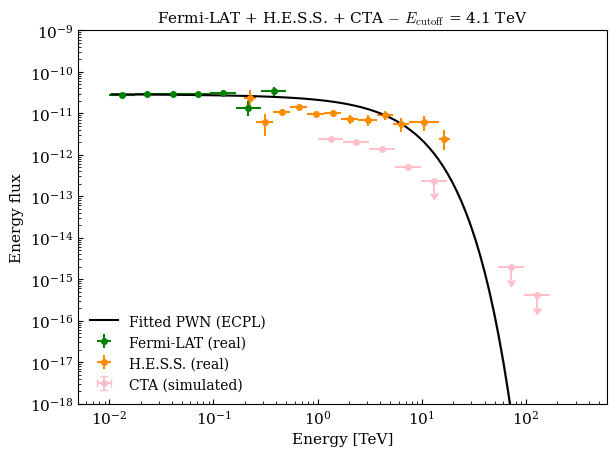

In [23]:
# ── Fermi+HESS+CTA (standalone, thesis-sized) ──────────────────────────────
sed_energy_edges = common_energy_axis.edges
fermi_energy_axis = flux_points_fermi.geom.axes["energy"]
fermi_e_min, fermi_e_max = fermi_energy_axis.edges.min(), fermi_energy_axis.edges.max()
E_broadband_min = min(fermi_e_min, sed_energy_edges[0])
E_broadband_max = max(fermi_e_max, sed_energy_edges[-1])

e_cutoff_cta = (1.0 / pwn_fit_fhc.spectral_model.lambda_.quantity).to("TeV")
e_cutoff_cta_err = e_cutoff_cta * abs(
    pwn_fit_fhc.spectral_model.lambda_.error / pwn_fit_fhc.spectral_model.lambda_.value
)

fig, ax = plt.subplots(figsize=(6.3, 4.7))
flux_points_fermi.plot(ax=ax, sed_type="e2dnde", color="green", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax, sed_type="e2dnde", color="darkorange", label="H.E.S.S. (real)")
flux_points_cta_fhc.plot(ax=ax, sed_type="e2dnde", color="pink", marker="o", label="CTA (simulated)")
pwn_fit_fhc.spectral_model.plot(ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
                                 sed_type="e2dnde", color="black", label="Fitted PWN (ECPL)")
pwn_fit_fhc.spectral_model.plot_error(ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
                                       sed_type="e2dnde", facecolor="gray", edgecolor="none", alpha=0.4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(E_broadband_min.to_value("TeV") * 0.5, E_broadband_max.to_value("TeV") * 2)
ax.set_ylim(1e-18, 1e-9)
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel("Energy flux")
ax.set_title(rf"Fermi-LAT + H.E.S.S. + CTA $-$ $E_{{\rm cutoff}}$ = {e_cutoff_cta:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig("fermi_hess_cta_sed_thesis.png")
plt.show()

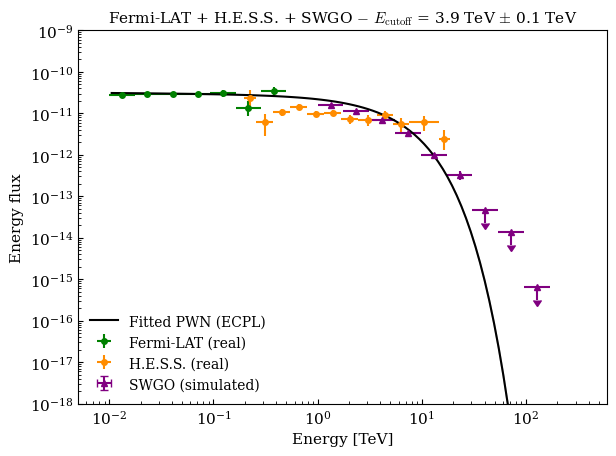

In [24]:
# ── Fermi+HESS+SWGO (standalone, thesis-sized) ─────────────────────────────
e_cutoff_swgo = (1.0 / pwn_fit_fhs.spectral_model.lambda_.quantity).to("TeV")
e_cutoff_swgo_err = e_cutoff_swgo * abs(
    pwn_fit_fhs.spectral_model.lambda_.error / pwn_fit_fhs.spectral_model.lambda_.value
)

fig, ax = plt.subplots(figsize=(6.3, 4.7))
flux_points_fermi.plot(ax=ax, sed_type="e2dnde", color="green", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax, sed_type="e2dnde", color="darkorange", label="H.E.S.S. (real)")
flux_points_swgo_fhs.plot(ax=ax, sed_type="e2dnde", color="purple", marker="^", label="SWGO (simulated)")
pwn_fit_fhs.spectral_model.plot(ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
                                 sed_type="e2dnde", color="black", label="Fitted PWN (ECPL)")
pwn_fit_fhs.spectral_model.plot_error(ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
                                       sed_type="e2dnde", facecolor="gray", edgecolor="none", alpha=0.4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(E_broadband_min.to_value("TeV") * 0.5, E_broadband_max.to_value("TeV") * 2)
ax.set_ylim(1e-18, 1e-9)
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel("Energy flux")
ax.set_title(rf"Fermi-LAT + H.E.S.S. + SWGO $-$ $E_{{\rm cutoff}}$ = {e_cutoff_swgo:.1f} $\pm$ {e_cutoff_swgo_err:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig("fermi_hess_swgo_sed_thesis.png")
plt.show()

In [25]:
# ── SWGO-alone fit, checked against the known injected truth ────────────────
# datasets_swgo_fhs / pwn_fit_fhs already exist from the patched cell above
# (mask_fit already applied there -- fine to reuse, this isolates the SWGO
# data itself, not the joint-weighting question).

pwn_fit_swgo_only = pwn_fit_fhs.copy(name="pwn-ecpl-swgo-only")
halo_fit_swgo_only = halo_fit_fhs.copy(name="halo-swgo-only")

datasets_swgo_only = copy.deepcopy(datasets_swgo_fhs)
for d in datasets_swgo_only:
    d.models = Models([pwn_fit_swgo_only, halo_fit_swgo_only,
                        FoVBackgroundModel(dataset_name=d.name)])
    d.background_model.spectral_model.norm.min = 0.0

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_swgo_only = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_swgo_only = fit_swgo_only.run(datasets_swgo_only)

print(results_swgo_only)

lambda_par = pwn_fit_swgo_only.spectral_model.lambda_
index_par = pwn_fit_swgo_only.spectral_model.index
true_e_cutoff = (1.0 / PWN_LAMBDA_).to("TeV")

if lambda_par.value != 0:
    e_cutoff = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_err = e_cutoff * rel_err
    print(f"\nSWGO-alone fitted E_cutoff = {e_cutoff:.3f} +/- {e_cutoff_err:.3f}")
else:
    print("\nlambda_ fitted to (near) 0.")

print(f"TRUE injected E_cutoff       = {true_e_cutoff:.3f}")
print(f"TRUE injected index         = {PWN_INDEX}")
print(f"SWGO-alone fitted index     = {index_par.value:.3f} +/- {index_par.error:.3f}")
print(f"\nDeviation from truth: "
      f"{abs(e_cutoff.to_value('TeV') - true_e_cutoff.to_value('TeV')) / e_cutoff_err.to_value('TeV'):.1f} sigma "
      f"on E_cutoff" if lambda_par.value != 0 else "")

W VariableMetricBuilder No improvement in line search
W VariableMetricBuilder Edm is limited by Machine accuracy - return current minimum
W VariableMetricBuilder Reached machine accuracy limit; Edm 0.065558 is smaller than machine limit 8.00718 while 0.006 was requested
W VariableMetricBuilder No convergence; Edm 0.065558 is above tolerance 0.06
W DavidonErrorUpdator delgam < 0 : first derivatives increasing along search line (details in info log)
W VariableMetricBuilder No improvement in line search


W VariableMetricBuilder Reached machine accuracy limit; Edm 0.0107224 is smaller than machine limit 8.00718 while 0.006 was requested
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 815
	total stat : -134338262.86

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


SWGO-alone fitted E_cutoff = 9.700 TeV +/- 0.536 TeV
TRUE injected E_cutoff       = 10.000 TeV
TRUE injected index         = 2.54
SWGO-alone fitted index     = 2.525 +/- 0.017

Deviation from truth: 0.6 sigma on E_cutoff


In [26]:
from pathlib import Path

FERMI_DIR = Path("/project/ls-gruen/users/asu.uenver/fermi/")   # or wherever it's defined
FL16Y_CATALOG_FITS = FERMI_DIR / "gll_psc_v40.fit" # <-- point this at your downloaded FL16Y catalog
FL16Y_SEARCH_RADIUS = 1.0 * u.deg

if not FL16Y_CATALOG_FITS.exists():
    print(f"FL16Y_CATALOG_FITS not found at {FL16Y_CATALOG_FITS}.")
    print("Download gll_psc_v40.fit from "
          "https://fermi.gsfc.nasa.gov/ssc/data/access/lat/fl16y/draft.html "
          "and update FL16Y_CATALOG_FITS above.")
else:
    fl16y_table = Table.read(str(FL16Y_CATALOG_FITS), hdu=1)
    fl16y_coords = SkyCoord(ra=fl16y_table["RAJ2000"], dec=fl16y_table["DEJ2000"], unit="deg", frame="icrs")
    sep = fl16y_coords.separation(SOURCE_CENTER)
    nearby = fl16y_table[sep < FL16Y_SEARCH_RADIUS]
    nearby_sep = sep[sep < FL16Y_SEARCH_RADIUS]

    print(f"FL16Y sources within {FL16Y_SEARCH_RADIUS} of {SOURCE_CENTER.to_string('hmsdms')}:")
    if len(nearby) == 0:
        print("   (none)")
    else:
        order = np.argsort(nearby_sep)
        for i in order:
            row = nearby[i]
            name = row["Source_Name"] if "Source_Name" in row.colnames else row["NickName"]
            class1 = row["CLASS1"] if "CLASS1" in row.colnames else "?"
            assoc1 = row["ASSOC1"] if "ASSOC1" in row.colnames else ""
            print(f"   {name:25s} sep={nearby_sep[i].to('deg'):.3f}  CLASS1={class1!r:>8}  ASSOC1={assoc1!r}")


FL16Y sources within 1.0 deg of 18h38m03.130008s -06d55m33.39984s:
   FL16Y J1838.9-0704e       sep=0.270 deg  CLASS1= 'pwn  '  ASSOC1='HESS J1837-069              '
   FL16Y J1836.5-0651e       sep=0.372 deg  CLASS1= 'pwn  '  ASSOC1='HESS J1837-069              '
   FL16Y J1838.1-0622        sep=0.555 deg  CLASS1= 'unk  '  ASSOC1='NVSS J183802-062326         '
   FL16Y J1836.9-0725        sep=0.558 deg  CLASS1= 'unk  '  ASSOC1='NVSS J183646-072151         '
   FL16Y J1836.0-0729        sep=0.756 deg  CLASS1= 'unk  '  ASSOC1='NVSS J183606-073106         '
   FL16Y J1837.1-0610        sep=0.783 deg  CLASS1=  masked  ASSOC1=masked
   FL16Y J1837.7-0602        sep=0.879 deg  CLASS1= 'PSR  '  ASSOC1='PSR J1837-0604              '
   FL16Y J1838.7-0602        sep=0.897 deg  CLASS1=  masked  ASSOC1=masked
   FL16Y J1834.5-0630        sep=0.954 deg  CLASS1=  masked  ASSOC1=masked
   FL16Y J1834.6-0725        sep=0.973 deg  CLASS1=  masked  ASSOC1=masked
   FL16Y J1834.1-0706e       sep=0.992 

## Pure SED-level joint fit: Fermi + H.E.S.S. + CTA + SWGO, all as flux points




In [27]:
# ── CTA's own flux points, from the already-fit CTA-alone model (independent of
#    any joint-fit compromise) ────────────────────────────────────────────────
dataset_cta_only_resampled = resample_to_common_energy_axis(dataset_cta_only, common_energy_axis)

fpe_cta_alone = FluxPointsEstimator(
    energy_edges=common_energy_axis.edges,
    source=pwn_fit_cta_only.name,
    selection_optional="all",
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    flux_points_cta_alone = fpe_cta_alone.run(Datasets([dataset_cta_only_resampled]))

print("CTA-alone flux points (from the CTA-alone best-fit model):")
print(flux_points_cta_alone.to_table(sed_type="dnde", formatted=True))


E VariableMetricBuilder Initial matrix not pos.def.


E VariableMetricBuilder Initial matrix not pos.def.
CTA-alone flux points (from the CTA-alone best-fit model):
 e_ref   e_min   e_max        dnde      ...  counts  success   norm_scan   
  TeV     TeV     TeV   1 / (TeV s cm2) ...                                
------- ------- ------- --------------- ... -------- ------- --------------
  1.330   1.000   1.769       8.775e-13 ... 111356.0    True 0.200 .. 5.000
  2.353   1.769   3.129       2.382e-13 ...  60571.0    True 0.200 .. 5.000
  4.162   3.129   5.535       5.164e-14 ...  38070.0    True 0.200 .. 5.000
  7.362   5.535   9.791       6.568e-15 ...  25354.0    True 0.200 .. 5.000
 13.023   9.791  17.321       4.316e-16 ...  15193.0    True 0.200 .. 5.000
 23.037  17.321  30.639      -3.603e-16 ...   8444.0    True 0.200 .. 5.000
 40.750  30.639  54.198      -5.591e-17 ...   4749.0    True 0.200 .. 5.000
 72.084  54.198  95.873      -8.235e-18 ...   2072.0    True 0.200 .. 5.000
127.513  95.873 169.593      -2.806e-19 ...   1376.0 

In [28]:
# ── SWGO's own flux points, from the already-fit SWGO-alone model ───────────
datasets_swgo_only_resampled = Datasets(
    [resample_to_common_energy_axis(d, common_energy_axis) for d in datasets_swgo_only]
)

fpe_swgo_alone = FluxPointsEstimator(
    energy_edges=common_energy_axis.edges,
    source=pwn_fit_swgo_only.name,
    selection_optional="all",
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    flux_points_swgo_alone = fpe_swgo_alone.run(datasets_swgo_only_resampled)

print("SWGO-alone flux points (from the SWGO-alone best-fit model):")
print(flux_points_swgo_alone.to_table(sed_type="dnde", formatted=True))


SWGO-alone flux points (from the SWGO-alone best-fit model):
 e_ref   e_min   e_max  ...        counts        success   norm_scan   
  TeV     TeV     TeV   ...                                            
------- ------- ------- ... -------------------- ------- --------------
  1.330   1.000   1.769 ...  6427213.0 .. 2314.0    True 0.200 .. 5.000
  2.353   1.769   3.129 ... 1147470.0 .. 35971.0    True 0.200 .. 5.000
  4.162   3.129   5.535 ...  137507.0 .. 95314.0    True 0.200 .. 5.000
  7.362   5.535   9.791 ...  27564.0 .. 116580.0    True 0.200 .. 5.000
 13.023   9.791  17.321 ...    6110.0 .. 60239.0    True 0.200 .. 5.000
 23.037  17.321  30.639 ...     1430.0 .. 2700.0    True 0.200 .. 5.000
 40.750  30.639  54.198 ...      666.0 .. 1270.0    True 0.200 .. 5.000
 72.084  54.198  95.873 ...       258.0 .. 406.0    True 0.200 .. 5.000
127.513  95.873 169.593 ...        94.0 .. 159.0    True 0.200 .. 5.000
225.562 169.593 300.000 ...         43.0 .. 55.0    True 0.200 .. 5.000


In [29]:
# ── The actual pure-SED joint fit: Fermi + H.E.S.S. + CTA(SED) + SWGO(SED) ───
pwn_fit_sed_joint = SkyModel(
    spatial_model=PointSpatialModel(lon_0=SOURCE_CENTER.ra, lat_0=SOURCE_CENTER.dec, frame="icrs"),
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=PWN_LAMBDA_,
    ),
    name="pwn-ecpl-sed-joint",
)
pwn_fit_sed_joint.spatial_model.lon_0.frozen = True
pwn_fit_sed_joint.spatial_model.lat_0.frozen = True
pwn_fit_sed_joint.spectral_model.reference.frozen = True
pwn_fit_sed_joint.spectral_model.lambda_.min = 1e-6
pwn_fit_sed_joint.spectral_model.lambda_.max = 10.0
pwn_fit_sed_joint.spectral_model.amplitude.min = 0.0
pwn_fit_sed_joint.spectral_model.index.min = 0.0
pwn_fit_sed_joint.spectral_model.index.max = 6.0
# amplitude, index, lambda_ all free -- no halo component here, since the halo's
# contribution was already profiled out per-bin when each instrument's flux
# points were estimated with source=<PWN model name> above.

fermi_dataset_sed = FluxPointsDataset(data=flux_points_fermi, name="fermi-sed-joint", models=[pwn_fit_sed_joint])
hess_dataset_sed  = FluxPointsDataset(data=flux_points_hess,  name="hess-sed-joint",  models=[pwn_fit_sed_joint])
cta_dataset_sed   = FluxPointsDataset(data=flux_points_cta_alone,  name="cta-sed-joint",  models=[pwn_fit_sed_joint])
swgo_dataset_sed  = FluxPointsDataset(data=flux_points_swgo_alone, name="swgo-sed-joint", models=[pwn_fit_sed_joint])

datasets_sed_joint = Datasets([fermi_dataset_sed, hess_dataset_sed, cta_dataset_sed, swgo_dataset_sed])

print("Per-dataset stat_sum() BEFORE fitting (sanity check on scale -- these should")
print("now all be comparable orders of magnitude, unlike the MapDataset version):")
for d in datasets_sed_joint:
    print(f"  {d.name:20s}: {d.stat_sum():.2f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_sed_joint = Fit(optimize_opts={"print_level": 1, "tol": 3, "strategy": 1})
    results_sed_joint = fit_sed_joint.run(datasets_sed_joint)

print(results_sed_joint)

lambda_par = pwn_fit_sed_joint.spectral_model.lambda_
if lambda_par.value != 0:
    e_cutoff_sed_joint = (1.0 / lambda_par.quantity).to("TeV")
    rel_err = abs(lambda_par.error / lambda_par.value) if lambda_par.value else np.nan
    e_cutoff_sed_joint_err = e_cutoff_sed_joint * rel_err
    print(f"\nPure SED-level joint fit E_cutoff = {e_cutoff_sed_joint:.3f} +/- {e_cutoff_sed_joint_err:.3f}")
    print(f"Pure SED-level joint fit index    = {pwn_fit_sed_joint.spectral_model.index.value:.3f} "
          f"+/- {pwn_fit_sed_joint.spectral_model.index.error:.3f}")
else:
    print("\nlambda_ fitted to (near) 0 -- no preferred cutoff.")

print(f"\nFor comparison (all using the ORIGINAL 10 TeV placeholder truth):")
print(f"  Injected truth E_cutoff                         = 10.000 TeV")
print(f"  CTA-alone (MapDataset)                          = 8.728 +/- 0.947 TeV")
print(f"  SWGO-alone (MapDataset)                          = 9.679 +/- 0.517 TeV")
print(f"  Fermi+HESS+CTA joint (MapDataset, free ampl.)   = 4.119 +/- 0.138 TeV")
print(f"  Fermi+HESS+SWGO joint (MapDataset, free ampl.)  = 2.679 +/- 0.049 TeV (MIGRAD unreliable)")


Per-dataset stat_sum() BEFORE fitting (sanity check on scale -- these should
now all be comparable orders of magnitude, unlike the MapDataset version):
  fermi-sed-joint     : 25287.37
  hess-sed-joint      : 686.65
  cta-sed-joint       : 44192.43
  swgo-sed-joint      : 1905.08
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 109
	total stat : 8627.17

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


Pure SED-level joint fit E_cutoff = 6.248 TeV +/- 0.336 TeV
Pure SED-level joint fit index    = 2.272 +/- 0.012

For comparison (all using the ORIGINAL 10 TeV placeholder truth):
  Injected truth E_cutoff                         = 10.000 TeV
  CTA-alone (MapDataset)                          = 8.728 +/- 0.947 TeV
  SWGO-alone (MapDataset)                          = 9.679 +/- 0.517 TeV
  Fermi+HESS+CTA joint (MapDataset, f

## Using the ACTUAL per-instrument SED files (not derived-in-notebook flux points)



In [57]:
# ── Load the real per-instrument SED files ───────────────────────────────────
# FluxPoints, Table and Path are already imported above (cells 2/8/14).

CTA_FP_FITS = Path("/project/ls-gruen/users/asu.uenver/cta_output_true_halo_final/cta_fp_halo_1_v2.fits")
SWGO_FP_FITS = Path("/project/ls-gruen/users/asu.uenver/swgo_output_true_halo_final/swgo_fp_halo_1_v2.fits")


def load_flux_points_robust(path, label):
    if not path.exists():
        print(f"✗ {label}: file not found at {path}")
        return None
    try:
        fp = FluxPoints.read(str(path))
        print(f"✓ {label}: loaded directly via FluxPoints.read() (gammapy-native format)")
        print(fp)
        print()
        return fp
    except Exception as e:
        print(f"✗ {label}: FluxPoints.read() failed ({type(e).__name__}: {e})")
        print(f"  Falling back to raw table inspection so we can fix the conversion...")
        t = Table.read(str(path))
        print(f"  Columns found: {t.colnames}")
        print(f"  Meta: {dict(t.meta)}")
        print(t[:5])
        print()
        return None


flux_points_cta_real = load_flux_points_robust(CTA_FP_FITS, "CTA")
flux_points_swgo_real = load_flux_points_robust(SWGO_FP_FITS, "SWGO")


✓ CTA: loaded directly via FluxPoints.read() (gammapy-native format)
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 13)
  quantities             : ['norm', 'norm_err', 'norm_ul', 'ts', 'sqrt_ts', 'npred', 'npred_excess', 'stat', 'stat_null', 'is_ul', 'counts', 'success']
  ref. model             : template
  n_sigma                : 1
  n_sigma_ul             : 2.0
  sqrt_ts_threshold_ul   : 2
  sed type init          : likelihood


✓ SWGO: loaded directly via FluxPoints.read() (gammapy-native format)
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 13)
  quantities             : ['norm', 'norm_err', 'ts', 'sqrt_ts', 'npred', 'npred_excess', 'stat', 'stat_null', 'counts', 'success']
  ref. model             : template
  n_sigma                : 1
  n_sigma_ul             : 2.0
  sqrt_ts_thre

=== Fermi+HESS+CTA (real SED file) — per-dataset stat_sum() BEFORE fitting ===
  fermi-fhc-real      : 25287.37
  hess-fhc-real       : 686.65
  cta-fhc-real        : 2915.95
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 120
	total stat : 1040.54

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.


Fermi+HESS+CTA (real SED) fitted parameters:
  index    = 2.1226 +/- 0.0077
  E_cutoff = 12.714 TeV +/- 0.520 TeV
  total stat = 1040.54

=== Fermi+HESS+SWGO (real SED file) — per-dataset stat_sum() BEFORE fitting ===
  fermi-fhs-real      : 25287.37
  hess-fhs-real       : 686.65
  swgo-fhs-real       : 1151.50
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 119
	total stat : 601.42

CovarianceResult

	backend    : minuit
	method 

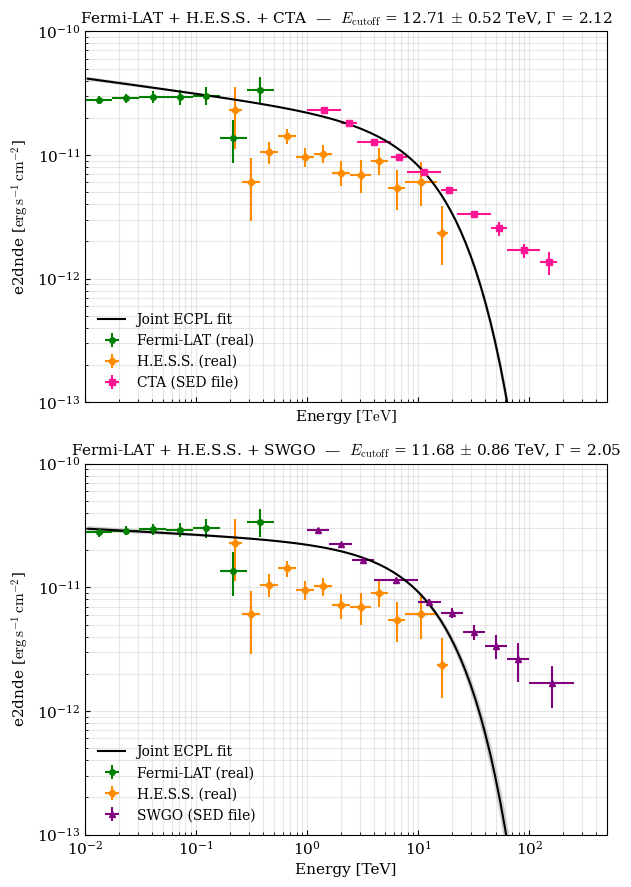


=== Summary ===
Fermi+HESS only (real data)   : E_cutoff = 22.006 +/- 13.282 TeV
Fermi+HESS+CTA  (real SED)    : E_cutoff = 12.714 +/- 0.520 TeV
Fermi+HESS+SWGO (real SED)    : E_cutoff = 11.685 +/- 0.864 TeV


In [58]:
# ============================================================
# SEPARATE SED-level joint fits (real CTA/SWGO files)
#   Fit 1: Fermi + HESS + CTA   (independent of SWGO)
#   Fit 2: Fermi + HESS + SWGO  (independent of CTA)
# ============================================================

# ---------- Fit 1: Fermi + HESS + CTA (real SED file) ----------
pwn_fit_sed_fhc_real = SkyModel(
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=1 / (10 * u.TeV),
    ),
    name="pwn-ecpl-fhc-real",
)
pwn_fit_sed_fhc_real.spectral_model.lambda_.min = 1e-6
pwn_fit_sed_fhc_real.spectral_model.lambda_.max = 10.0
pwn_fit_sed_fhc_real.spectral_model.amplitude.min = 0.0
pwn_fit_sed_fhc_real.spectral_model.index.min = 0.0
pwn_fit_sed_fhc_real.spectral_model.index.max = 6.0

fermi_dataset_fhc_real = FluxPointsDataset(
    models=[pwn_fit_sed_fhc_real], data=flux_points_fermi, name="fermi-fhc-real"
)
hess_dataset_fhc_real = FluxPointsDataset(
    models=[pwn_fit_sed_fhc_real], data=flux_points_hess, name="hess-fhc-real"
)
cta_dataset_fhc_real = FluxPointsDataset(
    models=[pwn_fit_sed_fhc_real], data=flux_points_cta_real, name="cta-fhc-real"
)

datasets_fhc_sed_real = Datasets([fermi_dataset_fhc_real, hess_dataset_fhc_real, cta_dataset_fhc_real])

print("=== Fermi+HESS+CTA (real SED file) — per-dataset stat_sum() BEFORE fitting ===")
for d in datasets_fhc_sed_real:
    print(f"  {d.name:20s}: {d.stat_sum():.2f}")

fit_fhc_sed_real = Fit()
result_fhc_sed_real = fit_fhc_sed_real.run(datasets=datasets_fhc_sed_real)
print(result_fhc_sed_real)

lam_fhc = pwn_fit_sed_fhc_real.spectral_model.lambda_
ecut_fhc = 1 / lam_fhc.quantity
ecut_fhc_err = (lam_fhc.error / lam_fhc.value**2) * u.TeV

print(f"\nFermi+HESS+CTA (real SED) fitted parameters:")
print(f"  index    = {pwn_fit_sed_fhc_real.spectral_model.index.value:.4f} "
      f"+/- {pwn_fit_sed_fhc_real.spectral_model.index.error:.4f}")
print(f"  E_cutoff = {ecut_fhc:.3f} +/- {ecut_fhc_err:.3f}")
print(f"  total stat = {datasets_fhc_sed_real.stat_sum():.2f}")


# ---------- Fit 2: Fermi + HESS + SWGO (real SED file) ----------
pwn_fit_sed_fhs_real = SkyModel(
    spectral_model=ExpCutoffPowerLawSpectralModel(
        amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF, lambda_=1 / (10 * u.TeV),
    ),
    name="pwn-ecpl-fhs-real",
)
pwn_fit_sed_fhs_real.spectral_model.lambda_.min = 1e-6
pwn_fit_sed_fhs_real.spectral_model.lambda_.max = 10.0
pwn_fit_sed_fhs_real.spectral_model.amplitude.min = 0.0
pwn_fit_sed_fhs_real.spectral_model.index.min = 0.0
pwn_fit_sed_fhs_real.spectral_model.index.max = 6.0

fermi_dataset_fhs_real = FluxPointsDataset(
    models=[pwn_fit_sed_fhs_real], data=flux_points_fermi, name="fermi-fhs-real"
)
hess_dataset_fhs_real = FluxPointsDataset(
    models=[pwn_fit_sed_fhs_real], data=flux_points_hess, name="hess-fhs-real"
)
swgo_dataset_fhs_real = FluxPointsDataset(
    models=[pwn_fit_sed_fhs_real], data=flux_points_swgo_real, name="swgo-fhs-real"
)

datasets_fhs_sed_real = Datasets([fermi_dataset_fhs_real, hess_dataset_fhs_real, swgo_dataset_fhs_real])

print("\n=== Fermi+HESS+SWGO (real SED file) — per-dataset stat_sum() BEFORE fitting ===")
for d in datasets_fhs_sed_real:
    print(f"  {d.name:20s}: {d.stat_sum():.2f}")

fit_fhs_sed_real = Fit()
result_fhs_sed_real = fit_fhs_sed_real.run(datasets=datasets_fhs_sed_real)
print(result_fhs_sed_real)

lam_fhs = pwn_fit_sed_fhs_real.spectral_model.lambda_
ecut_fhs = 1 / lam_fhs.quantity
ecut_fhs_err = (lam_fhs.error / lam_fhs.value**2) * u.TeV

print(f"\nFermi+HESS+SWGO (real SED) fitted parameters:")
print(f"  index    = {pwn_fit_sed_fhs_real.spectral_model.index.value:.4f} "
      f"+/- {pwn_fit_sed_fhs_real.spectral_model.index.error:.4f}")
print(f"  E_cutoff = {ecut_fhs:.3f} +/- {ecut_fhs_err:.3f}")
print(f"  total stat = {datasets_fhs_sed_real.stat_sum():.2f}")


# ============================================================
# Two-panel plot: Fermi+HESS+CTA (top) / Fermi+HESS+SWGO (bottom)
# ============================================================
E_plot_min = 0.01 * u.TeV
E_plot_max = 300 * u.TeV

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(6.3, 9.0), sharex=True)

# --- Top: Fermi+HESS+CTA ---
flux_points_fermi.plot(ax=ax_top, sed_type="e2dnde", color="green", marker="o", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax_top, sed_type="e2dnde", color="darkorange", marker="D", label="H.E.S.S. (real)")
flux_points_cta_real.plot(ax=ax_top, sed_type="e2dnde", color="deeppink", marker="s", label="CTA (SED file)")

pwn_fit_sed_fhc_real.spectral_model.plot(
    ax=ax_top, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
    color="black", label="Joint ECPL fit"
)
pwn_fit_sed_fhc_real.spectral_model.plot_error(
    ax=ax_top, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
    facecolor="gray", edgecolor="none", alpha=0.35
)

ax_top.set_title(
    f"Fermi-LAT + H.E.S.S. + CTA  —  "
    f"$E_\\mathrm{{cutoff}}$ = {ecut_fhc.value:.2f} $\\pm$ {ecut_fhc_err.value:.2f} TeV, "
    f"$\\Gamma$ = {pwn_fit_sed_fhc_real.spectral_model.index.value:.2f}"
)
ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.set_xlim(1e-2, 5e2)
ax_top.set_ylim(1e-13, 1e-10)
ax_top.legend(loc="lower left")
ax_top.grid(alpha=0.3, which="both")

# --- Bottom: Fermi+HESS+SWGO ---
flux_points_fermi.plot(ax=ax_bot, sed_type="e2dnde", color="green", marker="o", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax_bot, sed_type="e2dnde", color="darkorange", marker="D", label="H.E.S.S. (real)")
flux_points_swgo_real.plot(ax=ax_bot, sed_type="e2dnde", color="purple", marker="^", label="SWGO (SED file)")

pwn_fit_sed_fhs_real.spectral_model.plot(
    ax=ax_bot, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
    color="black", label="Joint ECPL fit"
)
pwn_fit_sed_fhs_real.spectral_model.plot_error(
    ax=ax_bot, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
    facecolor="gray", edgecolor="none", alpha=0.35
)

ax_bot.set_title(
    f"Fermi-LAT + H.E.S.S. + SWGO  —  "
    f"$E_\\mathrm{{cutoff}}$ = {ecut_fhs.value:.2f} $\\pm$ {ecut_fhs_err.value:.2f} TeV, "
    f"$\\Gamma$ = {pwn_fit_sed_fhs_real.spectral_model.index.value:.2f}"
)
ax_bot.set_xscale("log")
ax_bot.set_yscale("log")
ax_bot.set_xlim(1e-2, 5e2)
ax_bot.set_ylim(1e-13, 1e-10)
ax_bot.set_xlabel("Energy [TeV]")
ax_bot.legend(loc="lower left")
ax_bot.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("fermi_hess_cta_swgo_separate_sed_fits.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Summary ===")
print(f"Fermi+HESS only (real data)   : E_cutoff = 22.006 +/- 13.282 TeV")
print(f"Fermi+HESS+CTA  (real SED)    : E_cutoff = {ecut_fhc.value:.3f} +/- {ecut_fhc_err.value:.3f} TeV")
print(f"Fermi+HESS+SWGO (real SED)    : E_cutoff = {ecut_fhs.value:.3f} +/- {ecut_fhs_err.value:.3f} TeV")

## Model comparison: PL vs. log-parabola (LP) vs. ECPL, for both joint fits

Adds two alternative spectral shapes -- a plain `PowerLawSpectralModel` (PL) and a
`LogParabolaSpectralModel` (LP) -- fit to the *same* combined flux points as the ECPL fit
above, separately for the Fermi+HESS+CTA and Fermi+HESS+SWGO scenarios. Each model gets its
own fresh `SkyModel`/`FluxPointsDataset` copies (gammapy requires one shared model instance
per joint fit, so PL, LP, and ECPL can't reuse the same `SkyModel` object), then all three
are compared with the fit statistic and AIC:

$$\mathrm{AIC} = \mathrm{stat} + 2k,$$

where `stat` is `Datasets.stat_sum()` (chi-square for `FluxPointsDataset`s) and $k$ is the
number of free parameters in that model. Lower AIC is preferred; $\Delta\mathrm{AIC}$ below
2 is usually considered indistinguishable, whereas differences of more than ~10 are usually
regarded as decisive.


In [59]:
from gammapy.modeling.models import LogParabolaSpectralModel


def fit_alt_model(name, spectral_model, flux_points_third, third_label):
    """Fit `spectral_model` jointly to Fermi-LAT + H.E.S.S. + one third instrument's real
    flux points, exactly mirroring how the ECPL fits above were set up: one shared SkyModel,
    one fresh FluxPointsDataset per instrument, combined in a single Datasets/Fit() call.
    """
    model = SkyModel(spectral_model=spectral_model, name=name)
    datasets = Datasets([
        FluxPointsDataset(models=[model], data=flux_points_fermi, name=f"fermi-{name}"),
        FluxPointsDataset(models=[model], data=flux_points_hess, name=f"hess-{name}"),
        FluxPointsDataset(models=[model], data=flux_points_third, name=f"{third_label}-{name}"),
    ])
    result = Fit().run(datasets=datasets)
    stat = datasets.stat_sum()
    k = len(model.parameters.free_parameters)
    aic = stat + 2 * k
    return model, datasets, result, stat, k, aic


def print_model_comparison(label, rows):
    print(f"=== {label}: PL vs. LP vs. ECPL ===")
    best_aic = min(r[3] for r in rows)
    print(f"{'model':6s} {'stat':>10s} {'k':>3s} {'AIC':>10s} {'dAIC':>8s}")
    for name, stat, k, aic in rows:
        print(f"{name:6s} {stat:10.2f} {k:3d} {aic:10.2f} {aic - best_aic:8.2f}")
    print()


In [60]:
# ---------- PL and LP, Fermi+HESS+CTA (real SED file) ----------
pl_model_cta = PowerLawSpectralModel(amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF)
pl_model_cta.amplitude.min = 0.0
pl_model_cta.index.min = 0.0
pl_model_cta.index.max = 6.0

lp_model_cta = LogParabolaSpectralModel(
    amplitude=PWN_AMPLITUDE, alpha=PWN_INDEX, beta=0.1, reference=PWN_E_REF,
)
lp_model_cta.amplitude.min = 0.0
lp_model_cta.alpha.min = 0.0
lp_model_cta.alpha.max = 6.0
lp_model_cta.beta.min = -2.0
lp_model_cta.beta.max = 2.0

pwn_pl_fhc_real, datasets_pl_fhc_real, result_pl_fhc_real, stat_pl_fhc, k_pl_fhc, aic_pl_fhc = \
    fit_alt_model("pl-fhc-real", pl_model_cta, flux_points_cta_real, "cta")

pwn_lp_fhc_real, datasets_lp_fhc_real, result_lp_fhc_real, stat_lp_fhc, k_lp_fhc, aic_lp_fhc = \
    fit_alt_model("lp-fhc-real", lp_model_cta, flux_points_cta_real, "cta")

# stat/k/AIC for the ECPL fit already run above (pwn_fit_sed_fhc_real, datasets_fhc_sed_real)
k_ecpl_fhc = len(pwn_fit_sed_fhc_real.spectral_model.parameters.free_parameters)
stat_ecpl_fhc = datasets_fhc_sed_real.stat_sum()
aic_ecpl_fhc = stat_ecpl_fhc + 2 * k_ecpl_fhc

print_model_comparison(
    "Fermi+HESS+CTA (real SED)",
    [
        ("PL", stat_pl_fhc, k_pl_fhc, aic_pl_fhc),
        ("LP", stat_lp_fhc, k_lp_fhc, aic_lp_fhc),
        ("ECPL", stat_ecpl_fhc, k_ecpl_fhc, aic_ecpl_fhc),
    ],
)
print(f"PL   fitted: index = {pl_model_cta.index.value:.4f} +/- {pl_model_cta.index.error:.4f}")
print(f"LP   fitted: alpha = {lp_model_cta.alpha.value:.4f} +/- {lp_model_cta.alpha.error:.4f}, "
      f"beta = {lp_model_cta.beta.value:.4f} +/- {lp_model_cta.beta.error:.4f}")


=== Fermi+HESS+CTA (real SED): PL vs. LP vs. ECPL ===
model        stat   k        AIC     dAIC
PL        3191.16   2    3195.16  2665.88
LP         523.28   3     529.28     0.00
ECPL      1040.54   3    1046.54   517.25

PL   fitted: index = 2.3133 +/- 0.0026
LP   fitted: alpha = 2.3203 +/- 0.0063, beta = 0.0767 +/- 0.0023


In [61]:
# ---------- PL and LP, Fermi+HESS+SWGO (real SED file) ----------
pl_model_swgo = PowerLawSpectralModel(amplitude=PWN_AMPLITUDE, index=PWN_INDEX, reference=PWN_E_REF)
pl_model_swgo.amplitude.min = 0.0
pl_model_swgo.index.min = 0.0
pl_model_swgo.index.max = 6.0

lp_model_swgo = LogParabolaSpectralModel(
    amplitude=PWN_AMPLITUDE, alpha=PWN_INDEX, beta=0.1, reference=PWN_E_REF,
)
lp_model_swgo.amplitude.min = 0.0
lp_model_swgo.alpha.min = 0.0
lp_model_swgo.alpha.max = 6.0
lp_model_swgo.beta.min = -2.0
lp_model_swgo.beta.max = 2.0

pwn_pl_fhs_real, datasets_pl_fhs_real, result_pl_fhs_real, stat_pl_fhs, k_pl_fhs, aic_pl_fhs = \
    fit_alt_model("pl-fhs-real", pl_model_swgo, flux_points_swgo_real, "swgo")

pwn_lp_fhs_real, datasets_lp_fhs_real, result_lp_fhs_real, stat_lp_fhs, k_lp_fhs, aic_lp_fhs = \
    fit_alt_model("lp-fhs-real", lp_model_swgo, flux_points_swgo_real, "swgo")

k_ecpl_fhs = len(pwn_fit_sed_fhs_real.spectral_model.parameters.free_parameters)
stat_ecpl_fhs = datasets_fhs_sed_real.stat_sum()
aic_ecpl_fhs = stat_ecpl_fhs + 2 * k_ecpl_fhs

print_model_comparison(
    "Fermi+HESS+SWGO (real SED)",
    [
        ("PL", stat_pl_fhs, k_pl_fhs, aic_pl_fhs),
        ("LP", stat_lp_fhs, k_lp_fhs, aic_lp_fhs),
        ("ECPL", stat_ecpl_fhs, k_ecpl_fhs, aic_ecpl_fhs),
    ],
)
print(f"PL   fitted: index = {pl_model_swgo.index.value:.4f} +/- {pl_model_swgo.index.error:.4f}")
print(f"LP   fitted: alpha = {lp_model_swgo.alpha.value:.4f} +/- {lp_model_swgo.alpha.error:.4f}, "
      f"beta = {lp_model_swgo.beta.value:.4f} +/- {lp_model_swgo.beta.error:.4f}")


=== Fermi+HESS+SWGO (real SED): PL vs. LP vs. ECPL ===
model        stat   k        AIC     dAIC
PL        1186.38   2    1190.38   610.08
LP         574.30   3     580.30     0.00
ECPL       601.42   3     607.42    27.12

PL   fitted: index = 2.2169 +/- 0.0047
LP   fitted: alpha = 2.2617 +/- 0.0086, beta = 0.0638 +/- 0.0034


### Plot: PL / LP / ECPL overlaid on each joint fit


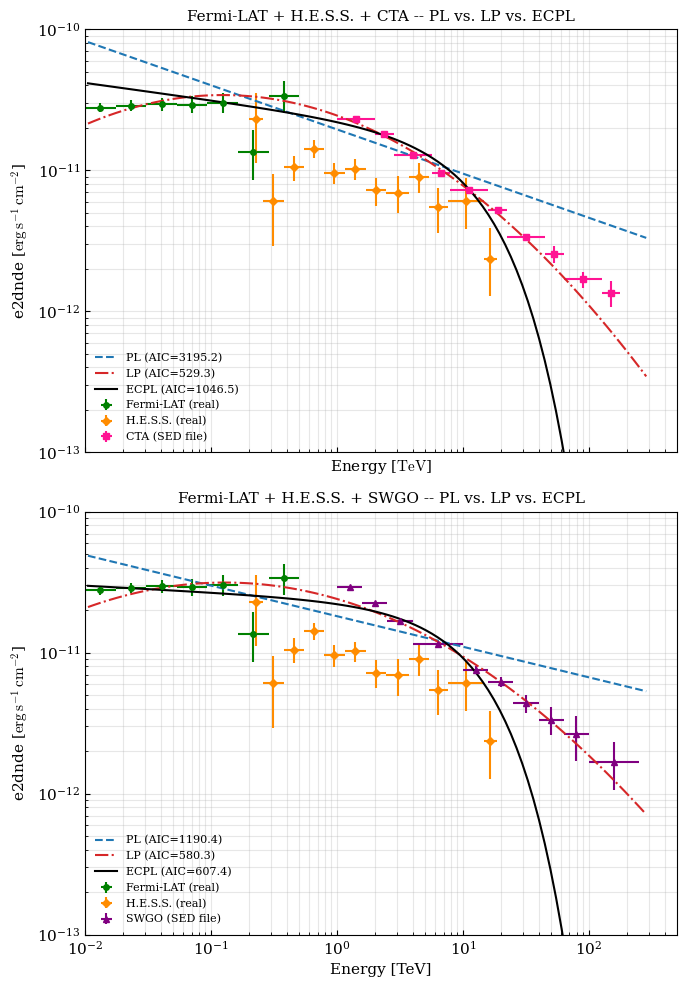

In [62]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(7.0, 10.0), sharex=True)

# --- Top: Fermi+HESS+CTA ---
flux_points_fermi.plot(ax=ax_top, sed_type="e2dnde", color="green", marker="o", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax_top, sed_type="e2dnde", color="darkorange", marker="D", label="H.E.S.S. (real)")
flux_points_cta_real.plot(ax=ax_top, sed_type="e2dnde", color="deeppink", marker="s", label="CTA (SED file)")

pl_model_cta.plot(ax=ax_top, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                   color="tab:blue", ls="--", label=f"PL (AIC={aic_pl_fhc:.1f})")
lp_model_cta.plot(ax=ax_top, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                   color="tab:red", ls="-.", label=f"LP (AIC={aic_lp_fhc:.1f})")
pwn_fit_sed_fhc_real.spectral_model.plot(ax=ax_top, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                                          color="black", label=f"ECPL (AIC={aic_ecpl_fhc:.1f})")

ax_top.set_title("Fermi-LAT + H.E.S.S. + CTA -- PL vs. LP vs. ECPL")
ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.set_xlim(1e-2, 5e2)
ax_top.set_ylim(1e-13, 1e-10)
ax_top.legend(loc="lower left", fontsize=8)
ax_top.grid(alpha=0.3, which="both")

# --- Bottom: Fermi+HESS+SWGO ---
flux_points_fermi.plot(ax=ax_bot, sed_type="e2dnde", color="green", marker="o", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax_bot, sed_type="e2dnde", color="darkorange", marker="D", label="H.E.S.S. (real)")
flux_points_swgo_real.plot(ax=ax_bot, sed_type="e2dnde", color="purple", marker="^", label="SWGO (SED file)")

pl_model_swgo.plot(ax=ax_bot, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                    color="tab:blue", ls="--", label=f"PL (AIC={aic_pl_fhs:.1f})")
lp_model_swgo.plot(ax=ax_bot, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                    color="tab:red", ls="-.", label=f"LP (AIC={aic_lp_fhs:.1f})")
pwn_fit_sed_fhs_real.spectral_model.plot(ax=ax_bot, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                                          color="black", label=f"ECPL (AIC={aic_ecpl_fhs:.1f})")

ax_bot.set_title("Fermi-LAT + H.E.S.S. + SWGO -- PL vs. LP vs. ECPL")
ax_bot.set_xscale("log")
ax_bot.set_yscale("log")
ax_bot.set_xlim(1e-2, 5e2)
ax_bot.set_ylim(1e-13, 1e-10)
ax_bot.set_xlabel("Energy [TeV]")
ax_bot.legend(loc="lower left", fontsize=8)
ax_bot.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("fermi_hess_cta_swgo_pl_lp_ecpl_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [63]:
# ---------- LP only, Fermi+HESS+CTA and Fermi+HESS+SWGO (real SED files) ----------
lp_model_cta = LogParabolaSpectralModel(
    amplitude=PWN_AMPLITUDE, alpha=PWN_INDEX, beta=0.1, reference=PWN_E_REF,
)
lp_model_cta.amplitude.min = 0.0
lp_model_cta.alpha.min = 0.0
lp_model_cta.alpha.max = 6.0
lp_model_cta.beta.min = -2.0
lp_model_cta.beta.max = 2.0

pwn_lp_fhc_real, datasets_lp_fhc_real, result_lp_fhc_real, stat_lp_fhc, k_lp_fhc, aic_lp_fhc = \
    fit_alt_model("lp-fhc-real", lp_model_cta, flux_points_cta_real, "cta")

lp_model_swgo = LogParabolaSpectralModel(
    amplitude=PWN_AMPLITUDE, alpha=PWN_INDEX, beta=0.1, reference=PWN_E_REF,
)
lp_model_swgo.amplitude.min = 0.0
lp_model_swgo.alpha.min = 0.0
lp_model_swgo.alpha.max = 6.0
lp_model_swgo.beta.min = -2.0
lp_model_swgo.beta.max = 2.0

pwn_lp_fhs_real, datasets_lp_fhs_real, result_lp_fhs_real, stat_lp_fhs, k_lp_fhs, aic_lp_fhs = \
    fit_alt_model("lp-fhs-real", lp_model_swgo, flux_points_swgo_real, "swgo")

print(f"Fermi+HESS+CTA  (real SED) LP fit: stat = {stat_lp_fhc:.2f}, k = {k_lp_fhc}")
print(f"  alpha = {lp_model_cta.alpha.value:.4f} +/- {lp_model_cta.alpha.error:.4f}")
print(f"  beta  = {lp_model_cta.beta.value:.4f} +/- {lp_model_cta.beta.error:.4f}\n")

print(f"Fermi+HESS+SWGO (real SED) LP fit: stat = {stat_lp_fhs:.2f}, k = {k_lp_fhs}")
print(f"  alpha = {lp_model_swgo.alpha.value:.4f} +/- {lp_model_swgo.alpha.error:.4f}")
print(f"  beta  = {lp_model_swgo.beta.value:.4f} +/- {lp_model_swgo.beta.error:.4f}")

Fermi+HESS+CTA  (real SED) LP fit: stat = 523.28, k = 3
  alpha = 2.3203 +/- 0.0063
  beta  = 0.0767 +/- 0.0023

Fermi+HESS+SWGO (real SED) LP fit: stat = 574.30, k = 3
  alpha = 2.2617 +/- 0.0086
  beta  = 0.0638 +/- 0.0034


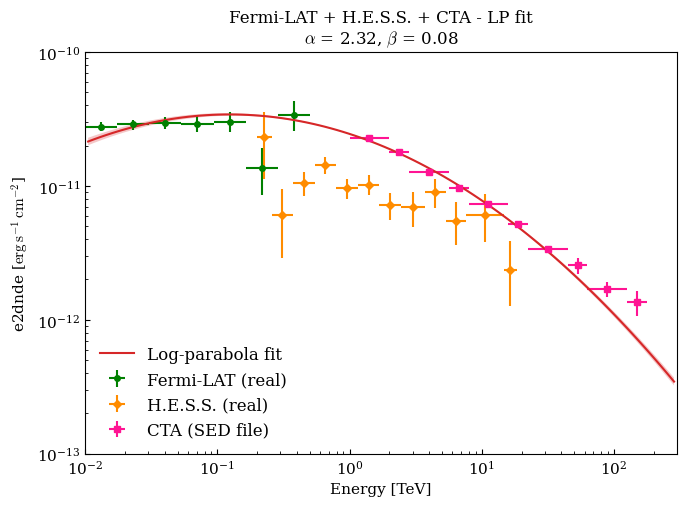

In [64]:
fig, ax = plt.subplots(figsize=(7.0, 5.2))

flux_points_fermi.plot(ax=ax, sed_type="e2dnde", color="green", marker="o", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax, sed_type="e2dnde", color="darkorange", marker="D", label="H.E.S.S. (real)")
flux_points_cta_real.plot(ax=ax, sed_type="e2dnde", color="deeppink", marker="s", label="CTA (SED file)")

lp_model_cta.plot(ax=ax, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                   color="tab:red", label="Log-parabola fit")
lp_model_cta.plot_error(ax=ax, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                         facecolor="tab:red", edgecolor="none", alpha=0.25)

ax.set_title(
    f"Fermi-LAT + H.E.S.S. + CTA - LP fit\n"
    f"$\\alpha$ = {lp_model_cta.alpha.value:.2f}, $\\beta$ = {lp_model_cta.beta.value:.2f}", fontsize=12
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-2, 3e2)
ax.set_ylim(1e-13, 1e-10)
ax.set_xlabel("Energy [TeV]")
ax.legend(loc="lower left", fontsize=12)

plt.tight_layout()
plt.savefig("fermi_hess_cta_lp_fit.pdf", dpi=300, bbox_inches="tight")
plt.show()

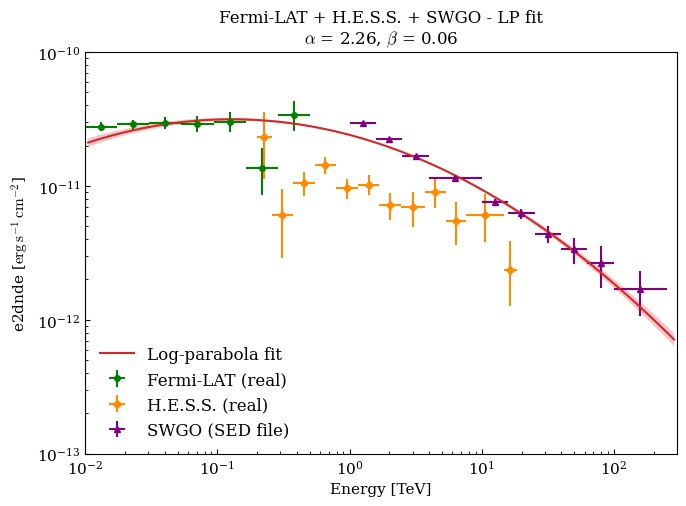

In [65]:
fig, ax = plt.subplots(figsize=(7.0, 5.2))

flux_points_fermi.plot(ax=ax, sed_type="e2dnde", color="green", marker="o", label="Fermi-LAT (real)")
flux_points_hess.plot(ax=ax, sed_type="e2dnde", color="darkorange", marker="D", label="H.E.S.S. (real)")
flux_points_swgo_real.plot(ax=ax, sed_type="e2dnde", color="purple", marker="^", label="SWGO (SED file)")

lp_model_swgo.plot(ax=ax, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                    color="tab:red", label="Log-parabola fit")
lp_model_swgo.plot_error(ax=ax, energy_bounds=[E_plot_min, E_plot_max], sed_type="e2dnde",
                          facecolor="tab:red", edgecolor="none", alpha=0.25)

ax.set_title(
    f"Fermi-LAT + H.E.S.S. + SWGO - LP fit\n"
    f"$\\alpha$ = {lp_model_swgo.alpha.value:.2f}, $\\beta$ = {lp_model_swgo.beta.value:.2f}" , fontsize=12
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-2, 3e2)
ax.set_ylim(1e-13, 1e-10)
ax.set_xlabel("Energy [TeV]")
ax.legend(loc="lower left", fontsize=12)

plt.tight_layout()
plt.savefig("fermi_hess_swgo_lp_fit.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
import os
import shutil
import numpy as np
from pathlib import Path
from gammapy.modeling.models import Models

OUTDIR = Path("all_joint")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---- 1. Flux points (the actual SED data points, per instrument) ----
flux_points_fermi.write(OUTDIR / "flux_points_fermi.fits", overwrite=True)
flux_points_hess.write(OUTDIR / "flux_points_hess.fits", overwrite=True)
flux_points_cta_real.write(OUTDIR / "flux_points_cta.fits", overwrite=True)
flux_points_swgo_real.write(OUTDIR / "flux_points_swgo.fits", overwrite=True)

# ---- 2. Best-fit models (spectral shape + params), as YAML ----
Models([pwn_fit_sed_fhc_real]).write(OUTDIR / "model_fermi_hess_cta.yaml", overwrite=True)
Models([pwn_fit_sed_fhs_real]).write(OUTDIR / "model_fermi_hess_swgo.yaml", overwrite=True)

# ---- 3. Fitted parameter tables + covariance matrices ----
pwn_fit_sed_fhc_real.parameters.to_table().write(
    OUTDIR / "fit_params_fermi_hess_cta.ecsv", overwrite=True
)
pwn_fit_sed_fhs_real.parameters.to_table().write(
    OUTDIR / "fit_params_fermi_hess_swgo.ecsv", overwrite=True
)
np.save(OUTDIR / "covariance_fermi_hess_cta.npy", pwn_fit_sed_fhc_real.covariance.data)
np.save(OUTDIR / "covariance_fermi_hess_swgo.npy", pwn_fit_sed_fhs_real.covariance.data)

# ---- 4. The full Datasets objects (data + model + mask together) ----
try:
    datasets_fhc_sed_real.write(
        filename=OUTDIR / "datasets_fermi_hess_cta.yaml", overwrite=True
    )
    datasets_fhs_sed_real.write(
        filename=OUTDIR / "datasets_fermi_hess_swgo.yaml", overwrite=True
    )
except Exception as e:
    print(f"  (Datasets.write() not supported for FluxPointsDataset in this gammapy "
          f"version: {e} -- flux points + models above are saved separately instead, "
          f"which covers the same info.)")

# ---- 5. Copy the SED plot in too, if it was already saved ----
plot_src = Path("fermi_hess_cta_swgo_separate_sed_fits.png")
if plot_src.exists():
    shutil.copy(plot_src, OUTDIR / plot_src.name)

# ---- 6. Human-readable summary ----
with open(OUTDIR / "summary.txt", "w") as f:
    f.write("=== Joint SED-level ECPL fits (real CTA/SWGO SED files) ===\n\n")
    f.write("Fermi+HESS only (real data):\n")
    f.write("  index = 2.2325, E_cutoff = 22.006 +/- 13.282 TeV\n\n")
    f.write("Fermi+HESS+CTA (real SED file):\n")
    f.write(f"  index    = {pwn_fit_sed_fhc_real.spectral_model.index.value:.4f} "
            f"+/- {pwn_fit_sed_fhc_real.spectral_model.index.error:.4f}\n")
    f.write(f"  E_cutoff = {ecut_fhc.value:.3f} +/- {ecut_fhc_err.value:.3f} TeV\n")
    f.write(f"  total stat = {datasets_fhc_sed_real.stat_sum():.2f}\n\n")
    f.write("Fermi+HESS+SWGO (real SED file):\n")
    f.write(f"  index    = {pwn_fit_sed_fhs_real.spectral_model.index.value:.4f} "
            f"+/- {pwn_fit_sed_fhs_real.spectral_model.index.error:.4f}\n")
    f.write(f"  E_cutoff = {ecut_fhs.value:.3f} +/- {ecut_fhs_err.value:.3f} TeV\n")
    f.write(f"  total stat = {datasets_fhs_sed_real.stat_sum():.2f}\n")

print(f"Saved everything to: {OUTDIR.resolve()}\n")
for p in sorted(OUTDIR.iterdir()):
    print(f"  {p.name}")

Saved everything to: /project/ls-gruen/users/asu.uenver/all_joint

  covariance_fermi_hess_cta.npy
  covariance_fermi_hess_swgo.npy
  cta-fhc-real.fits
  datasets_fermi_hess_cta.yaml
  datasets_fermi_hess_swgo.yaml
  fermi-fhc-real.fits
  fermi-fhs-real.fits
  fermi_hess_cta_swgo_separate_sed_fits.png
  fit_params_fermi_hess_cta.ecsv
  fit_params_fermi_hess_swgo.ecsv
  flux_points_cta.fits
  flux_points_fermi.fits
  flux_points_hess.fits
  flux_points_swgo.fits
  hess-fhc-real.fits
  hess-fhs-real.fits
  model_fermi_hess_cta.yaml
  model_fermi_hess_cta_covariance.dat
  model_fermi_hess_swgo.yaml
  model_fermi_hess_swgo_covariance.dat
  summary.txt
  swgo-fhs-real.fits


In [67]:
# ============================================================
# SUMMARY: print every important fitted value currently in memory
# ============================================================
import numpy as np
from gammapy.modeling.models import SkyModel
from gammapy.datasets import Datasets, Dataset

print("=" * 70)
print("ALL FITTED SKYMODELS (spectral parameters)")
print("=" * 70)
for _name, _val in sorted(globals().items()):
    if not isinstance(_val, SkyModel):
        continue
    sm = _val.spectral_model
    print(f"\n--- {_name}  (model name: '{_val.name}') ---")
    for _pname in ("amplitude", "index", "lambda_", "reference"):
        if hasattr(sm, _pname):
            p = getattr(sm, _pname)
            frozen = " [frozen]" if p.frozen else ""
            print(f"  {_pname:10s} = {p.value:.6g} {p.unit}  +/- {p.error:.4g}{frozen}")
    if hasattr(sm, "lambda_"):
        lam = sm.lambda_
        if lam.value not in (0, None) and not np.isnan(lam.value):
            e_cut = (1.0 / lam.quantity).to("TeV")
            rel_err = abs(lam.error / lam.value) if lam.value else np.nan
            print(f"  --> E_cutoff = {e_cut:.3f} +/- {(e_cut * rel_err):.3f}")
        else:
            print("  --> lambda_ = 0 (no preferred cutoff)")

print("\n" + "=" * 70)
print("ALL FIT RESULT OBJECTS (convergence / total stat)")
print("=" * 70)
for _name, _val in sorted(globals().items()):
    if hasattr(_val, "success") and hasattr(_val, "total_stat"):
        print(f"\n--- {_name} ---")
        print(f"  success    = {_val.success}")
        try:
            print(f"  total_stat = {_val.total_stat:.3f}")
        except Exception:
            pass
        print(f"  message    = {getattr(_val, 'message', 'n/a')}")

print("\n" + "=" * 70)
print("ALL DATASETS (per-dataset and total stat_sum)")
print("=" * 70)
for _name, _val in sorted(globals().items()):
    if isinstance(_val, (Datasets, Dataset)):
        try:
            print(f"  {_name:35s}: stat_sum = {_val.stat_sum():.3f}")
        except Exception as e:
            print(f"  {_name:35s}: (couldn't compute stat_sum: {e})")

ALL FITTED SKYMODELS (spectral parameters)

--- diffuse_true_cta  (model name: 'diffuse-cta-true') ---
  reference  = 1 TeV  +/- 0 [frozen]

--- halo_fit  (model name: 'halo-joint') ---
  amplitude  = 2.02071e-11 1 / (TeV s cm2)  +/- 1.004e-13
  index      = 2.54   +/- 0 [frozen]
  reference  = 0.95 TeV  +/- 0 [frozen]

--- halo_fit_cta_only  (model name: 'halo-cta-only') ---
  amplitude  = 1.99841e-11 1 / (TeV s cm2)  +/- 1.742e-13
  index      = 2.54   +/- 0 [frozen]
  reference  = 0.95 TeV  +/- 0 [frozen]

--- halo_fit_fc  (model name: 'halo-fermi-cta') ---
  amplitude  = 2.02297e-11 1 / (TeV s cm2)  +/- 1.734e-13
  index      = 2.54   +/- 0 [frozen]
  reference  = 0.95 TeV  +/- 0 [frozen]

--- halo_fit_fhc  (model name: 'halo-fermi-hess-cta') ---
  amplitude  = 2.05489e-11 1 / (TeV s cm2)  +/- 1.736e-13
  index      = 2.54   +/- 0 [frozen]
  reference  = 0.95 TeV  +/- 0 [frozen]

--- halo_fit_fhs  (model name: 'halo-fermi-hess-swgo') ---
  amplitude  = 2.02607e-11 1 / (TeV s cm2)  